# 07: Paper Visuals (Representative Topics)

> Validation note: canonical rescue results now come from the SCCKN Gemma 4 31B pipeline in `notebooks/llm_validation/` (8,558 final rescues). Gabriel outputs are historical.


In [14]:
from pathlib import Path
import sys
import warnings

import numpy as np
import pandas as pd
import matplotlib as mpl
import matplotlib.pyplot as plt
from matplotlib.patches import FancyBboxPatch, FancyArrowPatch, Rectangle
from matplotlib.colors import LinearSegmentedColormap, to_rgba
import seaborn as sns

warnings.filterwarnings('ignore')

def find_project_root() -> Path:
    """Anchor on config.txt — safe from any subdir depth."""
    for p in [Path.cwd().resolve(), *Path.cwd().resolve().parents]:
        if (p / "config.txt").exists():
            return p
    raise RuntimeError("config.txt not found")

PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.append(str(PROJECT_ROOT))

from src.io import (
    get_figure_dir,
    get_gabriel_dir,
    get_interim_dir,
    get_processed_dir,
    get_topic_dir,
)

INTERIM     = get_interim_dir()
PROCESSED   = get_processed_dir()
GABRIEL_DIR = get_gabriel_dir()
TOPIC_DIR   = get_topic_dir()
FIG_DIR     = get_figure_dir()
FIG_DIR.mkdir(parents=True, exist_ok=True)

# ── Global style ─────────────────────────────────────────────────────────────
mpl.rcParams.update({
    'figure.dpi':           120,
    'savefig.dpi':          300,
    'savefig.bbox':        'tight',
    'savefig.facecolor':   'white',
    'savefig.edgecolor':   'none',
    'pdf.fonttype':         42,   # editable text in vector PDFs
    'ps.fonttype':          42,
    'font.family':          'sans-serif',
    'font.sans-serif':      ['Helvetica', 'Arial', 'DejaVu Sans'],
    'font.size':            11,
    'axes.titlesize':       13,
    'axes.titleweight':    'bold',
    'axes.labelsize':       11,
    'axes.spines.top':      False,
    'axes.spines.right':    False,
    'axes.grid':            False,
    'legend.frameon':       False,
})

PAPER_BG    = '#ffffff'
PAPER_TEXT  = '#111827'
PAPER_MUTED = '#4b5563'
PAPER_GRID  = '#e5e7eb'

# Cluster colour anchors — three distinct, print-friendly hues for a white paper page.
CLUSTER_ANCHORS = {
    0: '#2b6cb0',   # blue
    1: '#c2413f',   # red
    2: '#238b45',   # green
}

RESCUE_THRESHOLD = 50
RANDOM_SEED      = 42
rng = np.random.default_rng(RANDOM_SEED)


def save_fig(fig, name: str) -> None:
    pdf = FIG_DIR / f'{name}.pdf'
    png = FIG_DIR / f'{name}.png'
    fig.savefig(pdf, facecolor=fig.get_facecolor(), edgecolor='none')
    fig.savefig(png, facecolor=fig.get_facecolor(), edgecolor='none')
    print(f'  saved → {pdf.name} + {png.name}')

In [15]:
user_stats      = pd.read_parquet(INTERIM   / 'user_stats.parquet')
# Figure 7 only needs the rating-edge count. Reading parquet metadata keeps the
# 200k representative notebook light on 8GB machines.
ratings_clustered_path = INTERIM / 'ratings_clustered.parquet'
try:
    import pyarrow.parquet as pq
    ratings_clustered_n_rows = int(pq.ParquetFile(ratings_clustered_path).metadata.num_rows)
except Exception:
    ratings_clustered_n_rows = int(len(pd.read_parquet(ratings_clustered_path, columns=['noteId'])))
ratings_clustered = None
cluster_summary = pd.read_parquet(INTERIM   / 'cluster_summary.parquet')
scores          = pd.read_parquet(PROCESSED / 'scores.parquet')
selection_log   = pd.read_parquet(PROCESSED / 'selection_log.parquet')
topic_notes     = pd.read_parquet(TOPIC_DIR / 'topic_notes.parquet')
topic_super_parent_notes = pd.read_parquet(TOPIC_DIR / 'topic_super_parent_notes.parquet')

# ── Gabriel data availability guard ──────────────────────────────────────
import re

GABRIEL_LABEL_COL = 'predicted_classes'
GABRIEL_SCORE_COL = 'rescue_worthiness'
GABRIEL_CLUSTER_IDS = []


def _approval_cluster_ids(df: pd.DataFrame) -> list[int]:
    if df is None:
        return []
    ids = []
    for col in df.columns:
        m = re.fullmatch(r'cluster_(\d+)_approval', str(col))
        if m and f'cluster_{m.group(1)}_count' in df.columns:
            ids.append(int(m.group(1)))
    return sorted(set(ids))


_gabriel_path = GABRIEL_DIR / 'gabriel_merged.parquet'
if _gabriel_path.exists():
    gabriel_merged = pd.read_parquet(_gabriel_path)
    missing = [c for c in ('noteId', GABRIEL_LABEL_COL, GABRIEL_SCORE_COL) if c not in gabriel_merged.columns]
    if missing:
        print(f'Gabriel data found but missing columns {missing}; Gabriel-dependent sections will be skipped.')
        gabriel_merged = None
        HAS_GABRIEL = False
    else:
        gabriel_merged['noteId'] = gabriel_merged['noteId'].astype(str)
        gabriel_merged[GABRIEL_LABEL_COL] = gabriel_merged[GABRIEL_LABEL_COL].astype('string')
        gabriel_merged[GABRIEL_SCORE_COL] = pd.to_numeric(gabriel_merged[GABRIEL_SCORE_COL], errors='coerce')
        GABRIEL_CLUSTER_IDS = _approval_cluster_ids(gabriel_merged)
        HAS_GABRIEL = len(GABRIEL_CLUSTER_IDS) > 0
        if not HAS_GABRIEL:
            print('Gabriel data found but no cluster approval/count columns were detected; Gabriel-dependent sections will be skipped.')
else:
    print(f'Gabriel data not available ({_gabriel_path}). Gabriel-dependent sections will be skipped.')
    gabriel_merged = None
    HAS_GABRIEL = False

# Normalise every noteId column to str up front — upstream parquets store
# int64 in some, str in others, and pandas-3 refuses to merge across types.
for df in (ratings_clustered, scores, topic_notes, topic_super_parent_notes, gabriel_merged):
    if df is not None and 'noteId' in df.columns:
        df['noteId'] = df['noteId'].astype(str)
selection_log['selected_noteId'] = selection_log['selected_noteId'].astype(str)

# Representative pool (NMR + passes the bridge threshold)
rep_pool = (
    selection_log[
        (selection_log['strategy'] == 'Representative')
        & selection_log['passes_bridge_threshold'].fillna(False)
        & (selection_log['status'] != 'CURRENTLY_RATED_HELPFUL')
    ]
    .drop_duplicates('selected_noteId')
    .rename(columns={'selected_noteId': 'noteId'})
    .copy()
)
rep_pool = rep_pool.merge(
    topic_notes[['noteId', 'topic_label']].drop_duplicates('noteId'),
    on='noteId', how='left',
)

print(f'user_stats         : {len(user_stats):>7,}')
print(f'representative pool: {len(rep_pool):>7,}')
print(f'gabriel_merged     : {len(gabriel_merged) if HAS_GABRIEL else "N/A":>7}')
print(f'super-parent notes : {len(topic_super_parent_notes):>7,}')
if HAS_GABRIEL:
    sourced_mask = gabriel_merged[GABRIEL_LABEL_COL].eq('sourced_factual_information')
    scored_mask = sourced_mask & gabriel_merged[GABRIEL_SCORE_COL].notna()
    rescued_mask = scored_mask & gabriel_merged[GABRIEL_SCORE_COL].ge(RESCUE_THRESHOLD)
    print(f'Gabriel clusters   : {GABRIEL_CLUSTER_IDS}')
    print(f'Gabriel sourced    : {int(sourced_mask.sum()):>7,}')
    print(f'Gabriel scored     : {int(scored_mask.sum()):>7,}')
    print(f'Gabriel rescued ≥{RESCUE_THRESHOLD}: {int(rescued_mask.sum()):>7,}')


user_stats         : 200,000
representative pool:  13,655
gabriel_merged     :   13550
super-parent notes :  38,227
Gabriel clusters   : [0, 1]
Gabriel sourced    :   8,602
Gabriel scored     :   8,601
Gabriel rescued ≥50:   8,511


## Figure 1 — Cluster Signatures Across High-Divergence Topics

Per-topic approval rates for the three recovered rater clusters. Dot area encodes topic note count; the cluster legend uses the paper-facing `Cl.` labels and adds user shares from Table 2.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


  saved → 07_fig1_cluster_signatures.pdf + 07_fig1_cluster_signatures.png


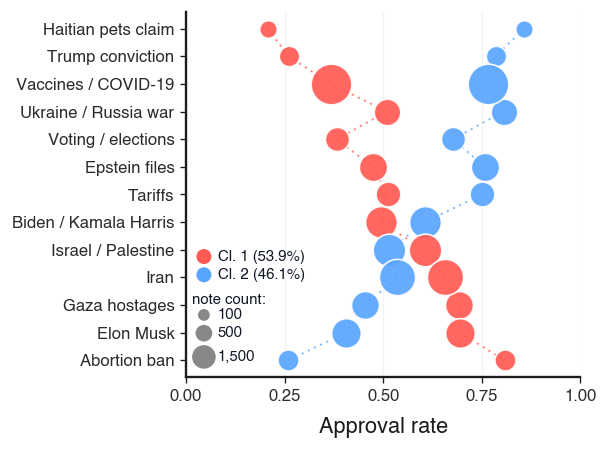

In [30]:
from matplotlib.lines import Line2D
import pandas as _pd
import numpy as _np

_stats = _pd.read_parquet(TOPIC_DIR / 'topic_cluster_stats.parquet')

INTERNAL_TO_PAPER = {0: 1, 1: 2}
PAPER_TO_INTERNAL = {v: k for k, v in INTERNAL_TO_PAPER.items()}
USER_SHARES = {1: 53.9, 2: 46.1}
CLUSTER_COLORS = {1: '#ff5a52', 2: '#58a5ff'}

# Figure-1 colour knobs. Cluster dot colours stay in CLUSTER_COLORS above.
NOTE_COUNT_DOT_COLOR = '#888888'   # grey dots in the note-count legend
TICK_LABEL_COLOR     = '#2C2C2E'  # numeric x ticks + topic labels
TICK_MARK_COLOR      = '#1C1C1E'  # small tick marks on axes
AXIS_LABEL_COLOR     = '#1C1C1E'  # 'Approval rate' label
FIG1_TITLE           = ''          # optional title; leave blank for no title
FIG1_TITLE_COLOR     = PAPER_TEXT
CLUSTER_LINE_COLORS  = {1: CLUSTER_COLORS[1], 2: CLUSTER_COLORS[2]}  # dotted lines
GRID_LINE_COLOR      = '#F2F2F7'  # vertical gridlines
SPINE_COLOR          = '#1C1C1E'  # left/bottom axis lines
LEGEND_TEXT_COLOR    = PAPER_TEXT

# ── TUNE THESE ───────────────────────────────────────────────────────────────
LEGEND_BOTTOM   = 0.03   # legend + bottom gap height (0=no gap, 0.25=large gap)
LEGEND_X        = 0      # legend horizontal position  (0=far left, 0.5=centre)
LEGEND_Y        = 0.02   # legend vertical position inside the plot (0=bottom, 1=top)

# Manual legend item positions, in axes coordinates. X: 0=left, 1=right; Y: 0=bottom, 1=top.
LEGEND_CL1_DOT_X = LEGEND_X + 0.045
LEGEND_CL1_DOT_Y = LEGEND_Y + 0.310
LEGEND_CL1_TEXT_X = LEGEND_X + 0.080
LEGEND_CL1_TEXT_Y = LEGEND_Y + 0.310

LEGEND_CL2_DOT_X = LEGEND_X + 0.045
LEGEND_CL2_DOT_Y = LEGEND_Y + 0.260
LEGEND_CL2_TEXT_X = LEGEND_X + 0.080
LEGEND_CL2_TEXT_Y = LEGEND_Y + 0.260

LEGEND_NOTE_COUNT_TEXT_X = LEGEND_X + 0.015
LEGEND_NOTE_COUNT_TEXT_Y = LEGEND_Y + 0.190

LEGEND_100_DOT_X = LEGEND_X + 0.045
LEGEND_100_DOT_Y = LEGEND_Y + 0.150
LEGEND_100_TEXT_X = LEGEND_X + 0.080
LEGEND_100_TEXT_Y = LEGEND_Y + 0.150

LEGEND_500_DOT_X = LEGEND_X + 0.045
LEGEND_500_DOT_Y = LEGEND_Y + 0.100
LEGEND_500_TEXT_X = LEGEND_X + 0.080
LEGEND_500_TEXT_Y = LEGEND_Y + 0.100

LEGEND_1500_DOT_X = LEGEND_X + 0.045
LEGEND_1500_DOT_Y = LEGEND_Y + 0.035
LEGEND_1500_TEXT_X = LEGEND_X + 0.080
LEGEND_1500_TEXT_Y = LEGEND_Y + 0.035

# Dot sizes are matplotlib scatter areas. Change these numbers by trial/error.
# Plot dots: actual dots inside the chart.
PLOT_NOTE_DOT_SIZES = {
    100: 200,
    500: 750,
    1500: 2100,
}
# Legend dots: reference dots shown next to note-count labels.
LEGEND_NOTE_DOT_SIZES = {
    100: 50,
    500: 100,
    1500: 200,
}
PLOT_DOT_WHITE_EDGE_WIDTH = 1  # white outline around plot dots (0=none, 2=strong)
# ─────────────────────────────────────────────────────────────────────────────

# Ordered by approval gap: Cl.2-dominant (top) → Cl.1-dominant (bottom)
TOPIC_LABELS = {
    'Springfield Pets Haitian Eating':          'Haitian pets claim',
    'Jury Business Records Trump':              'Trump conviction',
    'Vaccines Vaccine Covid Covid':             'Vaccines / COVID-19',
    'Ukraine Russia Crimea Invasion':           'Ukraine / Russia war',
    'Vote Elections Federal Elections':         'Voting / elections',
    'Epstein Files Epstein Files':              'Epstein files',
    'Tariffs Tariff Tariffs Paid':              'Tariffs',
    'Biden Joe Joe Biden':                      'Biden / Kamala Harris',
    'Palestine Israel Arabs Arab':              'Israel / Palestine',
    'Iran Iranian Iranians Irans':              'Iran',
    'Hostages Hostage Kidnapped Hamas':         'Gaza hostages',
    'Elon Elons Elon Elon':                     'Elon Musk',
    'Abortion Abortion Ban Ban':                'Abortion ban',
}
TOPIC_ORDER = list(TOPIC_LABELS.keys())
APPROVAL_COLS = {0: 'avg_cluster_0', 1: 'avg_cluster_1'}

def marker_area(notes, size_lookup=PLOT_NOTE_DOT_SIZES):
    counts = _np.array(sorted(size_lookup), dtype=float)
    areas = _np.array([size_lookup[int(n)] for n in counts], dtype=float)
    x = float(notes)
    if x <= counts[0]:
        slope = (areas[1] - areas[0]) / (counts[1] - counts[0])
        return max(1.0, float(areas[0] + (x - counts[0]) * slope))
    if x >= counts[-1]:
        slope = (areas[-1] - areas[-2]) / (counts[-1] - counts[-2])
        return max(1.0, float(areas[-1] + (x - counts[-1]) * slope))
    return max(1.0, float(_np.interp(x, counts, areas)))

def legend_size(notes):
    return marker_area(notes, LEGEND_NOTE_DOT_SIZES)

fig, ax = plt.subplots(figsize=(5.2, 4.0))
fig.patch.set_facecolor(PAPER_BG)
ax.set_facecolor(PAPER_BG)

_display_order = []
for raw_label in TOPIC_ORDER:
    row = _stats[_stats['topic_label'] == raw_label]
    if row.empty:
        continue
    _display_order.append((raw_label, row.iloc[0]))

for paper_c, internal_c in PAPER_TO_INTERNAL.items():
    xs, ys = [], []
    for raw_label, row in _display_order:
        xs.append(row[APPROVAL_COLS[internal_c]])
        ys.append(TOPIC_LABELS[raw_label])
    ax.plot(xs, ys, color=CLUSTER_LINE_COLORS.get(paper_c, CLUSTER_COLORS[paper_c]),
            linewidth=1.1, linestyle=(0, (1.2, 2.5)), alpha=0.75, zorder=2)

for raw_label, row in sorted(_display_order, key=lambda item: marker_area(item[1]['notes'])):
    display_label = TOPIC_LABELS[raw_label]
    notes = row['notes']
    for paper_c, internal_c in PAPER_TO_INTERNAL.items():
        ax.scatter(row[APPROVAL_COLS[internal_c]], display_label,
                   s=marker_area(notes), color=CLUSTER_COLORS[paper_c],
                   alpha=0.92, zorder=3, edgecolors='white',
                   linewidths=PLOT_DOT_WHITE_EDGE_WIDTH)

ax.set_xlabel('Approval rate', fontsize=13, labelpad=8, color=AXIS_LABEL_COLOR)
if FIG1_TITLE:
    ax.set_title(FIG1_TITLE, fontsize=13, pad=10, color=FIG1_TITLE_COLOR)
ax.set_xlim(0, 1)
ax.set_xticks([0, 0.25, 0.50, 0.75, 1.00])
ax.grid(axis='x', color=GRID_LINE_COLOR, linewidth=0.8)
ax.set_axisbelow(True)
ax.invert_yaxis()
ax.tick_params(axis='y', labelsize=10, color=TICK_MARK_COLOR, labelcolor=TICK_LABEL_COLOR)
ax.tick_params(axis='x', labelsize=10, color=TICK_MARK_COLOR, labelcolor=TICK_LABEL_COLOR)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
ax.spines['left'].set_linewidth(1.4)
ax.spines['bottom'].set_linewidth(1.4)
ax.spines['left'].set_color(SPINE_COLOR)
ax.spines['bottom'].set_color(SPINE_COLOR)

fig.subplots_adjust(bottom=LEGEND_BOTTOM)

def legend_dot(x, y, size, color):
    ax.scatter([x], [y], s=size, color=color, transform=ax.transAxes,
               edgecolors='none', linewidths=0, zorder=10, clip_on=False)

def legend_text(x, y, text):
    ax.text(x, y, text, transform=ax.transAxes, ha='left', va='center',
            fontsize=9, color=LEGEND_TEXT_COLOR, zorder=10, clip_on=False)

legend_dot(LEGEND_CL1_DOT_X, LEGEND_CL1_DOT_Y, 9 ** 2, CLUSTER_COLORS[1])
legend_text(LEGEND_CL1_TEXT_X, LEGEND_CL1_TEXT_Y, f'Cl. 1 ({USER_SHARES[1]:.1f}%)')
legend_dot(LEGEND_CL2_DOT_X, LEGEND_CL2_DOT_Y, 9 ** 2, CLUSTER_COLORS[2])
legend_text(LEGEND_CL2_TEXT_X, LEGEND_CL2_TEXT_Y, f'Cl. 2 ({USER_SHARES[2]:.1f}%)')

legend_text(LEGEND_NOTE_COUNT_TEXT_X, LEGEND_NOTE_COUNT_TEXT_Y, 'note count:')
legend_dot(LEGEND_100_DOT_X, LEGEND_100_DOT_Y, legend_size(100), NOTE_COUNT_DOT_COLOR)
legend_text(LEGEND_100_TEXT_X, LEGEND_100_TEXT_Y, '100')
legend_dot(LEGEND_500_DOT_X, LEGEND_500_DOT_Y, legend_size(500), NOTE_COUNT_DOT_COLOR)
legend_text(LEGEND_500_TEXT_X, LEGEND_500_TEXT_Y, '500')
legend_dot(LEGEND_1500_DOT_X, LEGEND_1500_DOT_Y, legend_size(1500), NOTE_COUNT_DOT_COLOR)
legend_text(LEGEND_1500_TEXT_X, LEGEND_1500_TEXT_Y, '1,500')
plt.tight_layout(rect=[0, LEGEND_BOTTOM, 1, 1])
save_fig(fig, '07_fig1_cluster_signatures')
plt.show()

## Figure 2 — How the Representative Rule Decides

Nine worked examples. For each note: per-cluster approval rate, the number of raters in that cluster that voted on the note (`n`), the computed bridge score, and the rule's verdict. We pick examples from four regimes:

1. **Confidently chosen** — high approval across all three clusters, bridge score well above the 0.50 threshold.
2. **Borderline** — bridge score just above 0.50; one cluster pulls the geometric mean down but the note still clears the bar.
3. **Low-bridge semantic rescues** — LLM-rated sourced/factual notes with strong rescue-worthiness scores, but bridge scores only barely above the Representative threshold.
4. **Not chosen** — one cluster strongly disapproves, so the geometric mean falls below the threshold and the note is rejected.

The bridge score itself is the geometric mean of the three per-cluster approval rates, so a single low cluster crushes the score — that is the entire mechanism by which the Representative rule rewards cross-cluster agreement.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


Figure 2 curated IDs not in current Gabriel pool; used fallback examples: ['2006311907980984632']
  saved → 07_fig2_representative_mechanism.pdf + 07_fig2_representative_mechanism.png


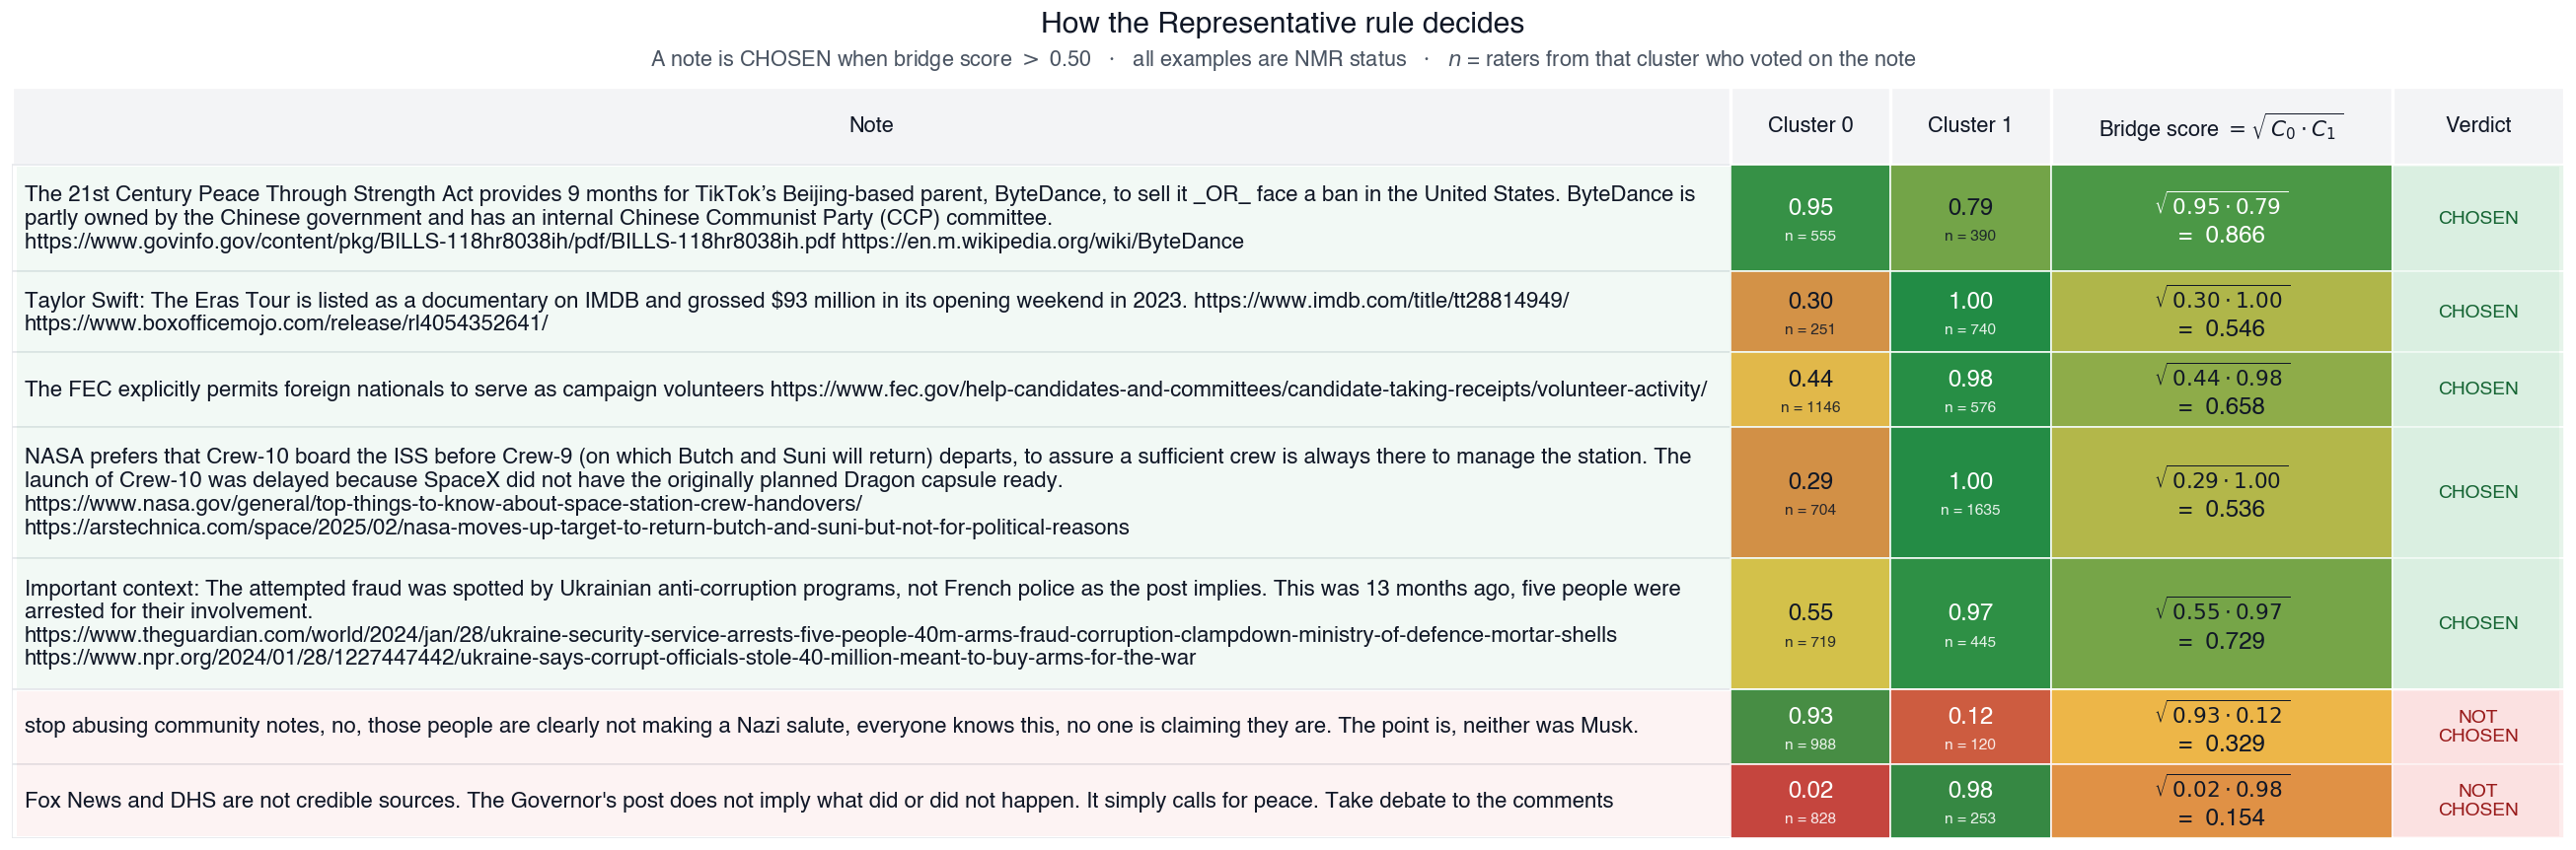

In [17]:
if not HAS_GABRIEL:
    print("Skip: Gabriel data not available.")
else:
    import textwrap, re
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    from matplotlib.colors import LinearSegmentedColormap

    scores_str = scores.copy()
    scores_str['noteId'] = scores_str['noteId'].astype(str)
    gm = gabriel_merged.copy()
    gm['noteId'] = gm['noteId'].astype(str)

    cluster_ids = list(GABRIEL_CLUSTER_IDS)
    BRIDGE_THRESHOLD = 0.50

    CONFIDENT_KEYWORDS = [
        'Azovstal steel plant in Mariupol',
        '21st Century Peace Through Strength Act provides 9 months',
    ]
    BORDERLINE_KEYWORDS = [
        "Eras Tour is listed as a documentary on IMDB",
        'FEC explicitly permits foreign nationals',
    ]
    NOT_CHOSEN_KEYWORDS = [
        'stop abusing community notes, no, those people are clearly',
        'Fox News and DHS are not credible sources',
    ]

    LOW_BRIDGE_SEMANTIC_RESCUE_IDS = [
        '1892590964742467737',  # NASA Crew-10 / ISS handover timing context
        '2006311907980984632',  # Star Tribune quote: police report says nothing stolen
        '1893121179046809620',  # Ukraine arms-fraud context: anti-corruption programs, not French police
    ]

    def find_in(df, needle):
        hit = df[df['summary'].str.contains(needle, na=False, regex=False)]
        return hit.iloc[0] if len(hit) else None

    candidates = []
    missing_curated = []

    for kw in CONFIDENT_KEYWORDS + BORDERLINE_KEYWORDS:
        hit = find_in(gm, kw)
        if hit is not None:
            candidates.append(hit)

    for note_id in LOW_BRIDGE_SEMANTIC_RESCUE_IDS:
        hit = gm[gm['noteId'].eq(note_id)]
        if len(hit):
            row = hit.iloc[0]
            if row.get('status') == 'NEEDS_MORE_RATINGS' and row.get('currentStatus') == 'NEEDS_MORE_RATINGS':
                candidates.append(row)
        else:
            missing_curated.append(note_id)

    for kw in NOT_CHOSEN_KEYWORDS:
        hit = find_in(scores_str, kw)
        if hit is not None:
            candidates.append(hit)

    seen_note_ids = set()
    unique_candidates = []
    for r in candidates:
        note_id = str(r.get('noteId', ''))
        if note_id and note_id not in seen_note_ids:
            seen_note_ids.add(note_id)
            unique_candidates.append(r)
    candidates = unique_candidates

    if len(candidates) < 6:
        needed = 6 - len(candidates)
        fallback = (
            gm[
                gm[GABRIEL_LABEL_COL].eq('sourced_factual_information')
                & pd.to_numeric(gm[GABRIEL_SCORE_COL], errors='coerce').ge(RESCUE_THRESHOLD)
                & gm['status'].eq('NEEDS_MORE_RATINGS')
                & ~gm['noteId'].isin(seen_note_ids)
            ]
            .sort_values(['bridge_score', GABRIEL_SCORE_COL], ascending=[True, False])
            .head(needed)
        )
        candidates.extend([r for _, r in fallback.iterrows()])

    if missing_curated:
        print(f'Figure 2 curated IDs not in current Gabriel pool; used fallback examples: {missing_curated}')
    if len(candidates) < 6:
        raise ValueError(f'Figure 2 needs at least 6 examples; found {len(candidates)}.')

    def clean_text(s: str) -> str:
        s = ' '.join(str(s).split())
        s = s.replace('&quot;', '"').replace('&amp;', '&').replace('&#39;', "'")
        s = re.sub(r'^N+N+\s*[-–—]\s*', '', s)
        s = re.sub(r'^NNN\s+', '', s)
        return s.strip()

    rows = []
    for r in candidates:
        row = {
            'note': clean_text(r['summary']),
            'bridge': float(r['bridge_score']),
        }
        for c in cluster_ids:
            app = pd.to_numeric(r.get(f'cluster_{c}_approval'), errors='coerce')
            n = pd.to_numeric(r.get(f'cluster_{c}_count'), errors='coerce')
            row[f'c{c}_app'] = float(app) if pd.notna(app) else np.nan
            row[f'c{c}_n'] = int(n) if pd.notna(n) else 0
        rows.append(row)

    table = pd.DataFrame(rows)
    n_rows = len(table)

    WRAP_CHARS = 175
    table['note_wrapped'] = table['note'].apply(
        lambda s: textwrap.fill(s, width=WRAP_CHARS, break_long_words=False, break_on_hyphens=False)
    )
    table['n_lines'] = table['note_wrapped'].apply(lambda t: t.count('\n') + 1)

    MIN_ROW_H    = 1.12
    LINE_HEIGHT  = 0.38
    ROW_VERT_PAD = 0.46
    row_heights = np.array([
        max(MIN_ROW_H, n_lines * LINE_HEIGHT + ROW_VERT_PAD)
        for n_lines in table['n_lines']
    ])

    BG       = PAPER_BG
    HEADER   = '#f3f4f6'
    GRID_FG  = PAPER_GRID
    TEXT     = PAPER_TEXT
    MUTED    = PAPER_MUTED

    total_body_h = row_heights.sum()
    header_h     = 1.18
    total_h      = header_h + total_body_h
    fig_height   = (total_h + 1.05) * 0.58

    fig, ax = plt.subplots(figsize=(22.0, fig_height))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.set_axis_off()
    fig.subplots_adjust(left=0.012, right=0.992, top=0.90, bottom=0.015)

    approval_cmap = LinearSegmentedColormap.from_list(
        'approval_light', ['#c2413f', '#f2c94c', '#238b45'], N=256,
    )

    def cell_facecolor(value: float):
        return approval_cmap(float(np.clip(value, 0, 1)))

    def text_on(rgba) -> str:
        r, g, b = rgba[:3]
        luma = 0.299 * r + 0.587 * g + 0.114 * b
        return '#111827' if luma > 0.55 else '#ffffff'

    if len(cluster_ids) == 2:
        bridge_label = r'Bridge score $= \sqrt{\,C_0 \cdot C_1\,}$'
    elif len(cluster_ids) == 3:
        bridge_label = r'Bridge score $= \sqrt[3]{\,C_0 \cdot C_1 \cdot C_2\,}$'
    else:
        bridge_label = 'Bridge score (geometric mean)'

    col_labels = ['Note'] + [f'Cluster {c}' for c in cluster_ids] + [bridge_label, 'Verdict']
    widths = np.array([8.80] + [0.82] * len(cluster_ids) + [1.75, 0.88])
    widths = widths / widths.sum()
    x_edges = np.concatenate([[0], np.cumsum(widths)])
    bridge_col_idx = 1 + len(cluster_ids)
    verdict_col_idx = bridge_col_idx + 1

    ax.set_xlim(0, 1)
    ax.set_ylim(0, total_h)

    for j, label in enumerate(col_labels):
        x0, x1 = x_edges[j], x_edges[j + 1]
        ax.add_patch(Rectangle((x0, total_h - header_h), x1 - x0, header_h,
                               facecolor=HEADER, edgecolor=BG, lw=2))
        ax.text((x0 + x1) / 2, total_h - header_h / 2, label,
                ha='center', va='center', color=TEXT, fontsize=13.0, fontweight='bold')

    def bridge_calc_text(row):
        vals = [row[f'c{c}_app'] for c in cluster_ids]
        vals_s = [f'{v:.2f}' for v in vals]
        if len(vals_s) == 2:
            return r'$\sqrt{\,' + r' \cdot '.join(vals_s) + r'\,}$'
        if len(vals_s) == 3:
            return r'$\sqrt[3]{\,' + r' \cdot '.join(vals_s) + r'\,}$'
        return r'$\mathrm{GM}_{' + str(len(vals_s)) + r'}$'

    y_cursor = total_h - header_h
    row_bounds = []
    for i in range(n_rows):
        rh = row_heights[i]
        y0 = y_cursor - rh
        r = table.iloc[i]
        row_bounds.append({'chosen': bool(r['bridge'] > BRIDGE_THRESHOLD), 'y0': y0, 'y1': y0 + rh})

        x0, x1 = x_edges[0], x_edges[1]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, rh, facecolor=BG, edgecolor=GRID_FG, lw=1))
        ax.text(x0 + 0.005, y0 + rh / 2, r['note_wrapped'],
                ha='left', va='center', fontsize=13.3, color=TEXT, linespacing=1.16)

        for cidx, c in enumerate(cluster_ids, start=1):
            ak, nk = f'c{c}_app', f'c{c}_n'
            xc0, xc1 = x_edges[cidx], x_edges[cidx + 1]
            face = cell_facecolor(r[ak])
            ax.add_patch(Rectangle((xc0, y0), xc1 - xc0, rh,
                                   facecolor=face, edgecolor=BG, lw=1))
            txt_col = text_on(face)
            ax.text((xc0 + xc1) / 2, y0 + rh / 2 + 0.15, f'{r[ak]:.2f}',
                    ha='center', va='center', fontsize=14.3, fontweight='bold', color=txt_col)
            ax.text((xc0 + xc1) / 2, y0 + rh / 2 - 0.27, f'n = {r[nk]}',
                    ha='center', va='center', fontsize=9.3, color=txt_col, alpha=0.88)

        xb0, xb1 = x_edges[bridge_col_idx], x_edges[bridge_col_idx + 1]
        bridge_face = cell_facecolor(0.2 + 0.8 * r['bridge'])
        ax.add_patch(Rectangle((xb0, y0), xb1 - xb0, rh,
                               facecolor=bridge_face, edgecolor=BG, lw=1))
        bridge_text_col = text_on(bridge_face)
        ax.text((xb0 + xb1) / 2, y0 + rh / 2 + 0.20, bridge_calc_text(r),
                ha='center', va='center', fontsize=13.0, color=bridge_text_col)
        ax.text((xb0 + xb1) / 2, y0 + rh / 2 - 0.27, f'=  {r["bridge"]:.3f}',
                ha='center', va='center', fontsize=14.5, fontweight='bold', color=bridge_text_col)

        xv0, xv1 = x_edges[verdict_col_idx], x_edges[verdict_col_idx + 1]
        is_chosen = r['bridge'] > BRIDGE_THRESHOLD
        verdict_face = '#e6f4ea' if is_chosen else '#fdecec'
        verdict_text = 'CHOSEN' if is_chosen else 'NOT\nCHOSEN'
        verdict_col = '#166534' if is_chosen else '#991b1b'
        ax.add_patch(Rectangle((xv0, y0), xv1 - xv0, rh,
                               facecolor=verdict_face, edgecolor=BG, lw=1))
        ax.text((xv0 + xv1) / 2, y0 + rh / 2, verdict_text,
                ha='center', va='center', fontsize=11.5, fontweight='bold',
                color=verdict_col, linespacing=1.15)
        y_cursor = y0

    group_start = 0
    outcome_group_colours = {True: '#16a34a', False: '#dc2626'}
    for idx in range(1, len(row_bounds) + 1):
        is_boundary = idx == len(row_bounds) or row_bounds[idx]['chosen'] != row_bounds[group_start]['chosen']
        if not is_boundary:
            continue
        chosen = row_bounds[group_start]['chosen']
        colour = outcome_group_colours[chosen]
        y0_group = min(row_bounds[j]['y0'] for j in range(group_start, idx))
        y1_group = max(row_bounds[j]['y1'] for j in range(group_start, idx))
        ax.add_patch(Rectangle((0.002, y0_group + 0.025), 0.996, y1_group - y0_group - 0.05,
                               facecolor=colour, edgecolor='none', alpha=0.055, zorder=2))
        group_start = idx

    fig.text(0.5, 0.965, 'How the Representative rule decides',
             color=TEXT, fontsize=18, fontweight='bold', ha='center')
    fig.text(0.5, 0.925,
             r'A note is CHOSEN when bridge score $>$ 0.50'
             r'   ·   all examples are NMR status'
             r'   ·   $n$ = raters from that cluster who voted on the note',
             color=MUTED, fontsize=13, ha='center')

    save_fig(fig, '07_fig2_representative_mechanism')
    plt.show()


## Figure 2b — Curated LLM Edge Cases with Low-Bridge Rescue and Rejection Labels

A sibling table to Figure 2 with the same visual grammar: note text, per-cluster approval, bridge score, and the LLM-side outcome. The examples are deliberately curated rather than representative: three bridge-qualified notes that Gabriel still rates as rescue-worthy despite sitting just above the Representative threshold, two notes Gabriel rejects as opinion/personal judgment, and two notes Gabriel rejects as hostile/troll/derogatory. Each note also reports its super-topic context.


Figure 2b curated IDs not in current Gabriel pool; used fallback examples: ['2030718937722429571', '1989003265829183851', '1880011003422814662', '1999532298845159454', '1892324036035960995', '1816510862045139266', '1966552364640329872']


1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


        llm_status llm_score                                super_topic   bridge
           Rescued        80 Ice Trump / Biden Project / Border Illegal 0.500077
           Rescued        85 Ice Trump / Biden Project / Border Illegal 0.500098
           Rescued        70 Hamas Israel / Flight Plane / Gun Firearms 0.500211
           Rescued        75 Hamas Israel / Flight Plane / Gun Firearms 0.500263
           Rescued        85 Ice Trump / Biden Project / Border Illegal 0.500280
           Rescued        85 Hamas Israel / Flight Plane / Gun Firearms 0.500294
Opinion / personal       n/a      Tesla Fsd / Game Games / Iphone Apple 0.945257
Opinion / personal       n/a Ice Trump / Biden Project / Border Illegal 1.000000
        Aggressive       n/a  Video Image / Flag Symbol / Contrails Sun 0.666041
Troll / derogatory       n/a                    Super-topic unavailable 0.688260
  saved → 07_fig2b_llm_edge_cases.pdf + 07_fig2b_llm_edge_cases.png


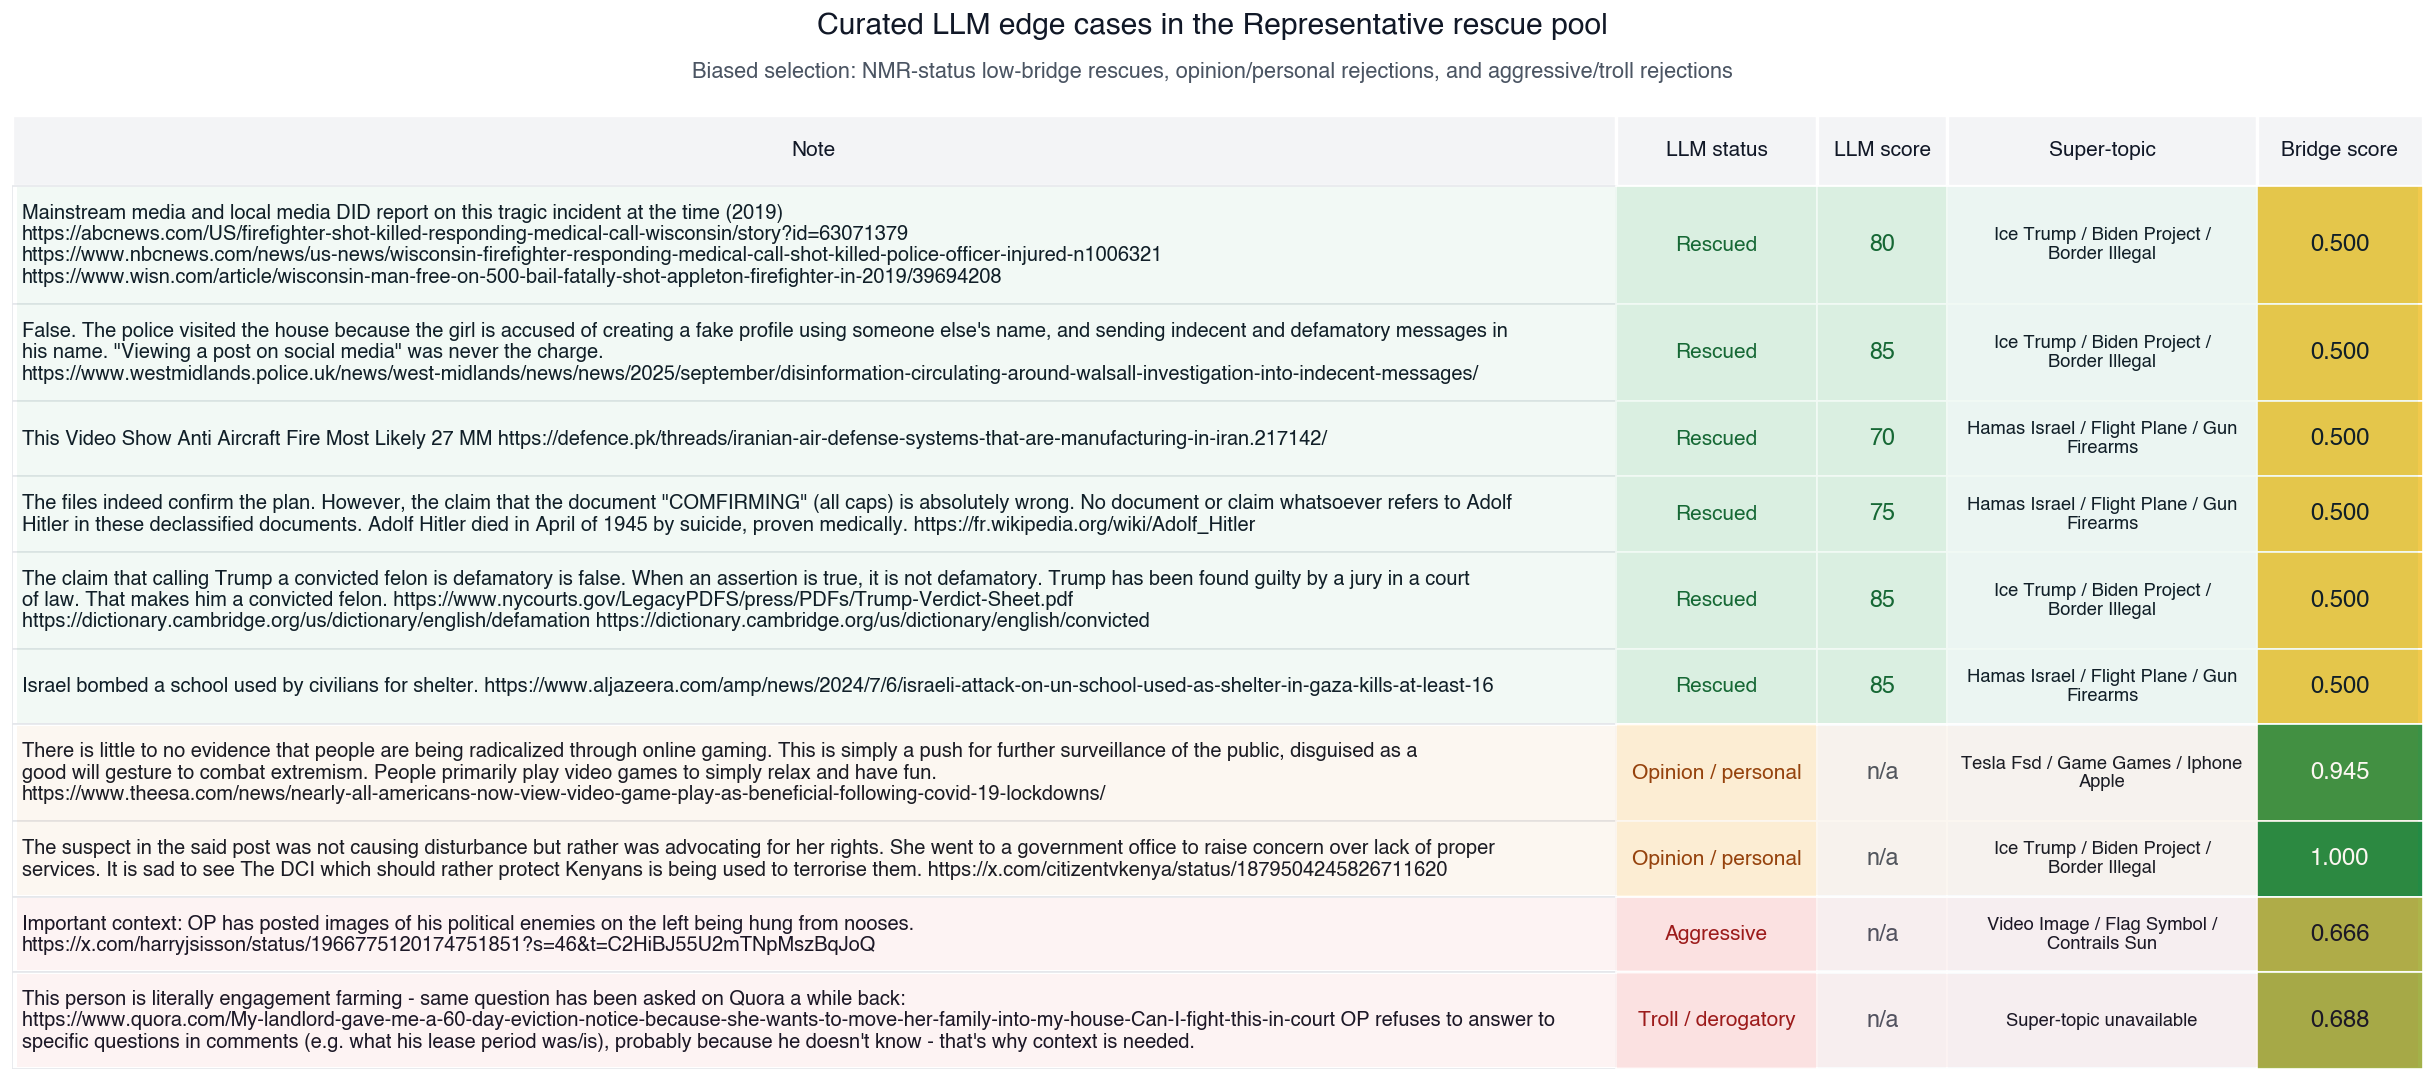

In [18]:
if not HAS_GABRIEL:
    print("Skip: Gabriel data not available.")
else:
    import textwrap, re
    import numpy as np
    import pandas as pd
    import matplotlib.pyplot as plt
    from matplotlib.patches import Rectangle
    from matplotlib.colors import LinearSegmentedColormap

    EDGE_CASE_NOTE_IDS = [
        # Gabriel rescue-worthy, but bridge score barely clears the Representative threshold.
        ('Rescued', '2030718937722429571'),
        ('Rescued', '1989003265829183851'),
        ('Rescued', '1880011003422814662'),
        ('Rescued', '1999532298845159454'),
        ('Rescued', '1892324036035960995'),
        ('Rescued', '1816510862045139266'),
        # Gabriel rejected as opinion/speculation; visually useful as personal-judgment examples.
        ('Opinion / personal', '1966552364640329872'),
        ('Opinion / personal', '1769106245074424109'),
        # Gabriel rejected as hostile/troll/derogatory; split into readable sub-buckets for the figure.
        ('Aggressive', '1966887085639692442'),
        ('Troll / derogatory', '1794497062601474389'),
    ]

    edge_base = gabriel_merged.copy()
    edge_base['noteId'] = edge_base['noteId'].astype(str)
    edge_topics = topic_super_parent_notes.copy()
    edge_topics['noteId'] = edge_topics['noteId'].astype(str)
    edge_base = edge_base.merge(
        edge_topics[['noteId', 'super_parent_label', 'parent_topic_label']].drop_duplicates('noteId'),
        on='noteId', how='left',
    )

    TARGET_COUNTS = {
        'Rescued': 6,
        'Opinion / personal': 2,
        'Aggressive': 1,
        'Troll / derogatory': 1,
    }

    selected = []
    missing_curated = []
    seen = set()
    for llm_status, note_id in EDGE_CASE_NOTE_IDS:
        hit = edge_base[edge_base['noteId'].eq(note_id)]
        if len(hit):
            row = hit.iloc[0].copy()
            row['llm_status'] = llm_status
            selected.append(row)
            seen.add(note_id)
        else:
            missing_curated.append(note_id)

    def add_fallback(llm_status, subset, n_needed):
        nonlocal_seen = seen
        if n_needed <= 0:
            return
        fallback = subset[~subset['noteId'].isin(nonlocal_seen)].head(n_needed)
        for _, row in fallback.iterrows():
            r = row.copy()
            r['llm_status'] = llm_status
            selected.append(r)
            nonlocal_seen.add(str(r['noteId']))

    score = pd.to_numeric(edge_base[GABRIEL_SCORE_COL], errors='coerce')
    rescued_fallback = (
        edge_base[
            edge_base[GABRIEL_LABEL_COL].eq('sourced_factual_information')
            & score.ge(RESCUE_THRESHOLD)
            & edge_base['status'].eq('NEEDS_MORE_RATINGS')
        ]
        .assign(_score=score)
        .sort_values(['bridge_score', '_score'], ascending=[True, False])
    )
    opinion_fallback = (
        edge_base[
            edge_base[GABRIEL_LABEL_COL].eq('opinion_or_speculation')
            & edge_base['status'].eq('NEEDS_MORE_RATINGS')
        ]
        .sort_values('bridge_score', ascending=False)
    )
    hostile_pool = edge_base[
        edge_base[GABRIEL_LABEL_COL].eq('hostile_troll_or_derogatory')
        & edge_base['status'].eq('NEEDS_MORE_RATINGS')
    ].copy()
    troll_mask = hostile_pool['summary'].str.contains(r'NNN|stop abusing|troll|joke|meme', case=False, na=False, regex=True)
    troll_fallback = hostile_pool[troll_mask].sort_values('bridge_score', ascending=False)
    aggressive_fallback = hostile_pool[~troll_mask].sort_values('bridge_score', ascending=False)
    if aggressive_fallback.empty:
        aggressive_fallback = hostile_pool.sort_values('bridge_score', ascending=False)
    if troll_fallback.empty:
        troll_fallback = hostile_pool.sort_values('bridge_score', ascending=False)

    current_counts = pd.Series([r['llm_status'] for r in selected]).value_counts().to_dict()
    add_fallback('Rescued', rescued_fallback, TARGET_COUNTS['Rescued'] - current_counts.get('Rescued', 0))
    current_counts = pd.Series([r['llm_status'] for r in selected]).value_counts().to_dict()
    add_fallback('Opinion / personal', opinion_fallback, TARGET_COUNTS['Opinion / personal'] - current_counts.get('Opinion / personal', 0))
    current_counts = pd.Series([r['llm_status'] for r in selected]).value_counts().to_dict()
    add_fallback('Aggressive', aggressive_fallback, TARGET_COUNTS['Aggressive'] - current_counts.get('Aggressive', 0))
    current_counts = pd.Series([r['llm_status'] for r in selected]).value_counts().to_dict()
    add_fallback('Troll / derogatory', troll_fallback, TARGET_COUNTS['Troll / derogatory'] - current_counts.get('Troll / derogatory', 0))

    edge_cases = pd.DataFrame(selected)
    edge_cases['noteId'] = edge_cases['noteId'].astype(str)
    order = {label: i for i, label in enumerate(TARGET_COUNTS)}
    edge_cases['_status_order'] = edge_cases['llm_status'].map(order)
    edge_cases = edge_cases.sort_values(['_status_order', 'bridge_score'], ascending=[True, True]).drop(columns='_status_order')
    if missing_curated:
        print(f'Figure 2b curated IDs not in current Gabriel pool; used fallback examples: {missing_curated}')

    def clean_text(s: str) -> str:
        s = str(s).replace('&quot;', '"').replace('&amp;', '&').replace('&#39;', "'")
        s = re.sub(r'^N+N+\s*[-–—]\s*', '', s)
        s = re.sub(r'^NNN\s*[-–—]?\s*', '', s)
        s = ' '.join(s.split())
        return textwrap.shorten(s.strip(), width=520, placeholder=' ...')

    def clean_topic(s: object) -> str:
        if pd.isna(s) or not str(s).strip():
            return 'Super-topic unavailable'
        return ' / '.join(part.strip() for part in str(s).split('/')[:3])

    def llm_score(row: pd.Series) -> str:
        score = row.get('rescue_worthiness')
        if pd.notna(score):
            return f'{float(score):.0f}'
        return 'n/a'

    rows = []
    for _, r in edge_cases.iterrows():
        rows.append({
            'note': clean_text(r['summary']),
            'llm_status': r['llm_status'],
            'llm_score': llm_score(r),
            'super_topic': clean_topic(r.get('super_parent_label')),
            'bridge': float(r['bridge_score']),
        })

    table = pd.DataFrame(rows)
    WRAP_NOTE_CHARS = 168
    WRAP_TOPIC_CHARS = 33
    table['note_wrapped'] = table['note'].apply(
        lambda s: textwrap.fill(
            s,
            width=WRAP_NOTE_CHARS,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )
    table['topic_wrapped'] = table['super_topic'].apply(
        lambda s: textwrap.fill(
            s,
            width=WRAP_TOPIC_CHARS,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )
    table['n_lines'] = table.apply(
        lambda r: max(r['note_wrapped'].count('\n') + 1, r['topic_wrapped'].count('\n') + 1),
        axis=1,
    )

    MIN_ROW_H    = 1.08
    LINE_HEIGHT  = 0.33
    ROW_VERT_PAD = 0.50
    row_heights = np.array([
        max(MIN_ROW_H, n_lines * LINE_HEIGHT + ROW_VERT_PAD)
        for n_lines in table['n_lines']
    ])

    BG       = PAPER_BG
    HEADER   = '#f3f4f6'
    GRID_FG  = PAPER_GRID
    TEXT     = PAPER_TEXT
    MUTED    = PAPER_MUTED

    total_body_h = row_heights.sum()
    header_h     = 1.08
    total_h      = header_h + total_body_h
    fig_height   = (total_h + 1.0) * 0.58

    fig, ax = plt.subplots(figsize=(20.5, fig_height))
    fig.patch.set_facecolor(BG)
    ax.set_facecolor(BG)
    ax.set_axis_off()
    fig.subplots_adjust(left=0.012, right=0.992, top=0.89, bottom=0.015)

    bridge_cmap = LinearSegmentedColormap.from_list(
        'bridge_edge_cases',
        ['#c2413f', '#f2c94c', '#238b45'],
        N=256,
    )

    def bridge_facecolor(value: float):
        return bridge_cmap(float(np.clip(value, 0, 1)))

    def text_on(rgba) -> str:
        r, g, b = rgba[:3]
        luma = 0.299 * r + 0.587 * g + 0.114 * b
        return '#111827' if luma > 0.55 else '#ffffff'

    status_colours = {
        'Rescued': ('#e6f4ea', '#166534'),
        'Opinion / personal': ('#fff4df', '#92400e'),
        'Aggressive': ('#fdecec', '#991b1b'),
        'Troll / derogatory': ('#fdecec', '#991b1b'),
    }
    group_frame_colours = {
        'Rescued': '#16a34a',
        'Opinion / personal': '#d97706',
        'Aggressive': '#dc2626',
        'Troll / derogatory': '#dc2626',
    }

    col_labels = ['Note', 'LLM status', 'LLM score', 'Super-topic', 'Bridge score']
    widths = np.array([8.90, 1.12, 0.72, 1.72, 0.92])
    widths = widths / widths.sum()
    x_edges = np.concatenate([[0], np.cumsum(widths)])

    ax.set_xlim(0, 1)
    ax.set_ylim(0, total_h)

    for j, label in enumerate(col_labels):
        x0, x1 = x_edges[j], x_edges[j + 1]
        ax.add_patch(Rectangle((x0, total_h - header_h), x1 - x0, header_h,
                               facecolor=HEADER, edgecolor=BG, lw=2))
        ax.text((x0 + x1) / 2, total_h - header_h / 2, label,
                ha='center', va='center', color=TEXT, fontsize=12.5, fontweight='bold')

    y_cursor = total_h - header_h
    row_bounds = []
    for i in range(len(table)):
        rh = row_heights[i]
        y0 = y_cursor - rh
        r = table.iloc[i]

        row_bounds.append({'status': r['llm_status'], 'y0': y0, 'y1': y0 + rh})

        # Note
        x0, x1 = x_edges[0], x_edges[1]
        ax.add_patch(Rectangle((x0, y0), x1 - x0, rh,
                               facecolor=BG, edgecolor=GRID_FG, lw=1))
        ax.text(x0 + 0.004, y0 + rh / 2, r['note_wrapped'],
                ha='left', va='center', fontsize=12, color=TEXT, linespacing=1.15)

        # LLM status
        xs0, xs1 = x_edges[1], x_edges[2]
        status_face, status_text = status_colours.get(r['llm_status'], ('#f3f4f6', TEXT))
        ax.add_patch(Rectangle((xs0, y0), xs1 - xs0, rh,
                               facecolor=status_face, edgecolor=BG, lw=1))
        ax.text((xs0 + xs1) / 2, y0 + rh / 2, r['llm_status'],
                ha='center', va='center', fontsize=12.5, fontweight='bold',
                color=status_text, linespacing=1.12)

        # LLM score
        xl0, xl1 = x_edges[2], x_edges[3]
        score_face = '#e6f4ea' if r['llm_score'] != 'n/a' else '#f9fafb'
        score_text = '#166534' if r['llm_score'] != 'n/a' else PAPER_MUTED
        ax.add_patch(Rectangle((xl0, y0), xl1 - xl0, rh,
                               facecolor=score_face, edgecolor=BG, lw=1))
        ax.text((xl0 + xl1) / 2, y0 + rh / 2, r['llm_score'],
                ha='center', va='center', fontsize=14.0, fontweight='bold', color=score_text)

        # Super-topic
        xt0, xt1 = x_edges[3], x_edges[4]
        ax.add_patch(Rectangle((xt0, y0), xt1 - xt0, rh,
                               facecolor='#f8fafc', edgecolor=BG, lw=1))
        ax.text((xt0 + xt1) / 2, y0 + rh / 2, r['topic_wrapped'],
                ha='center', va='center', fontsize=11.0, color=TEXT, linespacing=1.14)

        # Bridge score
        xb0, xb1 = x_edges[4], x_edges[5]
        face = bridge_facecolor(r['bridge'])
        ax.add_patch(Rectangle((xb0, y0), xb1 - xb0, rh,
                               facecolor=face, edgecolor=BG, lw=1))
        ax.text((xb0 + xb1) / 2, y0 + rh / 2, f'{r["bridge"]:.3f}',
                ha='center', va='center', fontsize=14.3, fontweight='bold', color=text_on(face))

        y_cursor = y0

    # Soft group halos: one shared frame for each contiguous LLM-status block.
    group_start = 0
    for idx in range(1, len(row_bounds) + 1):
        is_boundary = idx == len(row_bounds) or row_bounds[idx]['status'] != row_bounds[group_start]['status']
        if not is_boundary:
            continue
        status = row_bounds[group_start]['status']
        colour = group_frame_colours.get(status, PAPER_MUTED)
        y0_group = min(row_bounds[j]['y0'] for j in range(group_start, idx))
        y1_group = max(row_bounds[j]['y1'] for j in range(group_start, idx))
        pad_y = 0.025
        ax.add_patch(Rectangle((0.002, y0_group + pad_y), 0.996, y1_group - y0_group - 2 * pad_y,
                               facecolor=colour, edgecolor='none', alpha=0.055, zorder=18))
        group_start = idx

    fig.text(0.5, 0.965,
             'Curated LLM edge cases in the Representative rescue pool',
             color=TEXT, fontsize=18, fontweight='bold', ha='center')
    fig.text(0.5, 0.925,
             'Biased selection: NMR-status low-bridge rescues, opinion/personal rejections, and aggressive/troll rejections',
             color=MUTED, fontsize=13, ha='center')

    print(table[['llm_status', 'llm_score', 'super_topic', 'bridge']].to_string(index=False))
    save_fig(fig, '07_fig2b_llm_edge_cases')
    plt.show()


## Figure 3 — Note Pipeline With Dense-Core Cut

Revision of the pipeline chart Carina flagged: Bar 4 is removed, the top ~3% dense-core note cut is highlighted inside Bar 3, and a compact user-note matrix illustrates the dense overlap used for clustering.

1 extra bytes in post.stringData array
'created' timestamp seems very low; regarding as unix timestamp


  saved → 07_fig3_pool_and_topics.pdf + 07_fig3_pool_and_topics.png


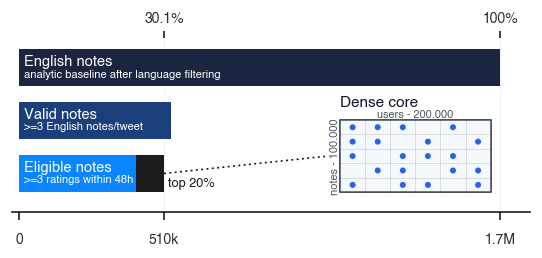

In [49]:
from matplotlib.patches import Rectangle, Circle
from matplotlib.colors import to_rgba

# ── Figure 3 base aliases ────────────────────────────────────────────────────
BG = PAPER_BG
TEXT = PAPER_TEXT
MUTED = PAPER_MUTED
GRID = '#cbd5e1'

# ── FIGURE 3 TUNE THESE: colours, lines, ticks, labels, matrix ───────────────
# Keep these independent from Figure 1 so you can tune this panel separately.
# Defaults reproduce the old Figure 3 as closely as possible.
FIG3_FIGURE_BG_COLOR = BG
FIG3_AXES_BG_COLOR = BG

# Optional figure title. Leave blank to keep the current no-title layout.
FIG3_TITLE = ''
FIG3_TITLE_COLOR = TEXT
FIG3_TITLE_FONTSIZE = 11.0
FIG3_TITLE_PAD = 8

# Main horizontal pipeline bars.
FIG3_STAGE_BAR_COLORS = {
    'english': '#1C2540',
    'valid': '#1A3F7A',
    'eligible': '#0A84FF',
}
FIG3_STAGE_BAR_EDGE_COLOR = 'none'
FIG3_STAGE_BAR_EDGE_WIDTH = 0.0
FIG3_STAGE_LABEL_COLOR = '#ffffff'
FIG3_STAGE_SUBTITLE_COLOR = '#ffffff'
FIG3_STAGE_LABEL_ALPHA = 1.0
FIG3_STAGE_SUBTITLE_ALPHA = 1.0

# Dense-core overlay inside the eligible-notes bar.
FIG3_DENSE_CORE_FILL_COLOR = '#1C1C1E'
FIG3_DENSE_CORE_ALPHA = 1.0
FIG3_DENSE_CORE_EDGE_COLOR = 'none'
FIG3_DENSE_CORE_EDGE_WIDTH = 0.0

# Top-20% annotation near the dense-core cut.
FIG3_TOP_LABEL_COLOR = '#1C1C1E'
FIG3_TOP_LABEL_FONTSIZE = 7.7
FIG3_TOP_LABEL_FONTWEIGHT = 'bold'
FIG3_ARROW_COLOR = '#1C1C1E'
FIG3_ARROW_LINE_WIDTH = 1.05
FIG3_ARROW_STYLE = '-|>'

# Main x-axis and manual bottom tick labels.
FIG3_BOTTOM_TICK_MARK_COLOR = '#1C1C1E'
FIG3_BOTTOM_TICK_LABEL_COLOR = '#2C2C2E'
FIG3_BOTTOM_TICK_WIDTH = 1.0
FIG3_BOTTOM_TICK_LENGTH = 5
FIG3_BOTTOM_SPINE_COLOR = '#1C1C1E'
FIG3_BOTTOM_SPINE_WIDTH = 1.0
FIG3_XLABEL_COLOR = '#1C1C1E'
FIG3_XLABEL_FONTSIZE = 9.0

# Top percentage axis.
FIG3_TOP_TICK_MARK_COLOR = '#1C1C1E'
FIG3_TOP_TICK_LABEL_COLOR = '#2C2C2E'
FIG3_TOP_TICK_WIDTH = 1.0
FIG3_TOP_TICK_LENGTH = 4
FIG3_TOP_SPINE_COLOR = '#1C1C1E'
FIG3_TOP_SPINE_WIDTH = 1.0

# Vertical guide lines at eligible / English note counts.
# Core / 100k guide line removed.
FIG3_GUIDE_LINE_COLOR = '#F2F2F7'
FIG3_GUIDE_LINE_STYLE = '-'
FIG3_GUIDE_LINE_WIDTH = 0.8
FIG3_GUIDE_LINE_ALPHA = 1.0

# Connector from dense-core bar segment to the matrix inset.
FIG3_CONNECTOR_COLOR = '#1C1C1E'
FIG3_CONNECTOR_STYLE = (0, (1.2, 2.0))
FIG3_CONNECTOR_WIDTH = 1.0
FIG3_CONNECTOR_ALPHA = 1.0

# Matrix inset text.
FIG3_MATRIX_TITLE_COLOR = TEXT
FIG3_MATRIX_NOTE_TEXT_COLOR = MUTED
FIG3_MATRIX_AXIS_LABEL_COLOR = MUTED

# Matrix inset frame, fill, grid, and dots.
FIG3_MATRIX_FACE_COLOR = '#ffffff'
FIG3_MATRIX_BORDER_COLOR = '#111827'
FIG3_MATRIX_TINT_COLOR = '#dbeafe'
FIG3_MATRIX_TINT_ALPHA = 0.25
FIG3_MATRIX_GRID_COLOR = '#111827'
FIG3_MATRIX_GRID_ALPHA = 0.16
FIG3_MATRIX_DOT_COLOR = '#2563eb'
FIG3_MATRIX_DOT_EDGE_COLOR = 'none'
FIG3_MATRIX_DOT_EDGE_WIDTH = 0.0

# Manual tick-label text values and colours.
# 100k bottom tick label removed.
FIG3_BOTTOM_TICK_LABELS = {
    'zero': '0',
    'eligible': '510k',
    'english': '1.7M',
}
FIG3_TOP_TICK_LABELS = {
    'eligible': '30.1%',
    'english': '100%',
}

english_notes = 1_693_711
valid_notes = 533_510
eligible_notes = 510_212
core_notes = 100_000
visual_core_notes = 100_000
DENSE_CORE_BAR_BLACK_ALPHA = FIG3_DENSE_CORE_ALPHA
selected_users = int(user_stats['raterParticipantId'].nunique()) if 'user_stats' in globals() else 200_000
core_share_eligible = core_notes / eligible_notes
core_share_english = core_notes / english_notes

# More compact vertical figure.
fig = plt.figure(figsize=(7.2, 2.50), facecolor=FIG3_FIGURE_BG_COLOR)
ax = fig.add_axes([0.075, 0.27, 0.60, 0.58])
ax.set_facecolor(FIG3_AXES_BG_COLOR)

if FIG3_TITLE:
    ax.set_title(FIG3_TITLE, color=FIG3_TITLE_COLOR, fontsize=FIG3_TITLE_FONTSIZE, pad=FIG3_TITLE_PAD)

stages = [
    ('English notes', english_notes, 'analytic baseline after language filtering', FIG3_STAGE_BAR_COLORS['english']),
    ('Valid notes', valid_notes, '>=3 English notes/tweet', FIG3_STAGE_BAR_COLORS['valid']),
    ('Eligible notes', eligible_notes, '>=3 ratings within 48h', FIG3_STAGE_BAR_COLORS['eligible']),
]

# Bars brought closer together vertically.
ys = [1.70, 0.85, 0.0]
bar_h = 0.60

# Shared left text anchor for all bar labels.
# Smaller = more left.
BAR_TEXT_X = 18_000

for y, (label, count, subtitle, color) in zip(ys, stages):
    ax.barh(
        y, count, height=bar_h, color=color,
        edgecolor=FIG3_STAGE_BAR_EDGE_COLOR, linewidth=FIG3_STAGE_BAR_EDGE_WIDTH,
        zorder=2,
    )

    # English notes was previously pushed right because count * 0.035 was large.
    # Now all stage labels use the same left anchor.
    ax.text(
        BAR_TEXT_X, y + 0.10, label,
        ha='left', va='center',
        fontsize=8.8, fontweight='bold',
        color=FIG3_STAGE_LABEL_COLOR,
        alpha=FIG3_STAGE_LABEL_ALPHA
    )
    ax.text(
        BAR_TEXT_X, y - 0.10, subtitle,
        ha='left', va='center',
        fontsize=6.7,
        color=FIG3_STAGE_SUBTITLE_COLOR,
        alpha=FIG3_STAGE_SUBTITLE_ALPHA
    )

# Highlight the dense-core note cut inside Bar 3 instead of drawing a separate Bar 4.
visual_core_x0 = eligible_notes - visual_core_notes
ax.add_patch(Rectangle(
    (visual_core_x0, ys[-1] - bar_h / 2),
    visual_core_notes,
    bar_h,
    facecolor=to_rgba(FIG3_DENSE_CORE_FILL_COLOR, DENSE_CORE_BAR_BLACK_ALPHA),
    edgecolor=FIG3_DENSE_CORE_EDGE_COLOR,
    linewidth=FIG3_DENSE_CORE_EDGE_WIDTH,
    zorder=4,
))

# --- Manual tuning knobs for the top-20% label and arrow ---------------------
# Slightly moved right on the x-axis.
TOP_LABEL_DX = 14_000
TOP_LABEL_DY = -bar_h * 0.28
ARROW_HEAD_DX = 5_000
ARROW_HEAD_DY = -bar_h * 0.28
ARROW_TAIL_DX_FROM_LABEL = -14_000

label_x = eligible_notes + TOP_LABEL_DX
label_y = ys[-1] + TOP_LABEL_DY
ax.text(
    label_x, label_y, 'top 20%',
    ha='left', va='center',
    fontsize=FIG3_TOP_LABEL_FONTSIZE,
    fontweight=FIG3_TOP_LABEL_FONTWEIGHT,
    color=FIG3_TOP_LABEL_COLOR
)
# Arrow removed; the compact label now sits immediately right of the dense-core segment.

ax.set_xlim(-25_000, 1_800_000)

# More compact vertical limits.
ax.set_ylim(-0.62, 2.18)

ax.set_yticks([])

# Core / 100k vertical guide line removed.
for x in [eligible_notes, english_notes]:
    ax.axvline(
        x,
        color=FIG3_GUIDE_LINE_COLOR,
        linestyle=FIG3_GUIDE_LINE_STYLE,
        linewidth=FIG3_GUIDE_LINE_WIDTH,
        alpha=FIG3_GUIDE_LINE_ALPHA,
        zorder=0,
    )

# Core / 100k tick mark removed from bottom x-axis.
ax.set_xticks([0, eligible_notes, english_notes])
ax.set_xticklabels(['', '', ''])
ax.tick_params(
    axis='x',
    length=FIG3_BOTTOM_TICK_LENGTH,
    width=FIG3_BOTTOM_TICK_WIDTH,
    color=FIG3_BOTTOM_TICK_MARK_COLOR,
    labelcolor=FIG3_BOTTOM_TICK_LABEL_COLOR,
)

for spine in ['left', 'right', 'top']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color(FIG3_BOTTOM_SPINE_COLOR)
ax.spines['bottom'].set_linewidth(FIG3_BOTTOM_SPINE_WIDTH)

# Bottom manual ticks. 100k label removed.
trans = ax.get_xaxis_transform()
manual_ticks = [
    (0, FIG3_BOTTOM_TICK_LABELS['zero'], -0.115, 'center'),
    (eligible_notes, FIG3_BOTTOM_TICK_LABELS['eligible'], -0.115, 'center'),
    (english_notes, FIG3_BOTTOM_TICK_LABELS['english'], -0.115, 'center'),
]

for x, label, yoff, ha in manual_ticks:
    if label:
        ax.text(
            x, yoff, label,
            transform=trans,
            ha=ha,
            va='top',
            fontsize=8.4,
            color=FIG3_BOTTOM_TICK_LABEL_COLOR
        )

# Bottom x-axis label removed:
# ax.set_xlabel('Absolute note count', fontsize=FIG3_XLABEL_FONTSIZE,
#               color=FIG3_XLABEL_COLOR, labelpad=16)

ax_top = ax.twiny()
ax_top.set_xlim(ax.get_xlim())

# Core / 5.9% top tick removed.
ax_top.set_xticks([eligible_notes, english_notes])
ax_top.set_xticklabels(
    [FIG3_TOP_TICK_LABELS['eligible'], FIG3_TOP_TICK_LABELS['english']],
    fontsize=8.4,
    color=FIG3_TOP_TICK_LABEL_COLOR,
)

ax_top.tick_params(
    axis='x',
    colors=FIG3_TOP_TICK_MARK_COLOR,
    labelcolor=FIG3_TOP_TICK_LABEL_COLOR,
    length=FIG3_TOP_TICK_LENGTH,
    width=FIG3_TOP_TICK_WIDTH,
)
ax_top.spines['top'].set_color(FIG3_TOP_SPINE_COLOR)
ax_top.spines['top'].set_linewidth(FIG3_TOP_SPINE_WIDTH)

for spine in ['left', 'right', 'bottom']:
    ax_top.spines[spine].set_visible(False)

# Schematic matrix drawn inside the bar-plot whitespace, not as a separate panel.
# --- Manual tuning knobs for the matrix inset -----------------------------
# MATRIX_X/Y move the whole matrix block. MATRIX_W/H resize it on x/y axes.
# MATRIX_SCALE grows/shrinks all matrix-related text, ticks, dots, borders,
# and grid lines together after you change MATRIX_W/H.
MATRIX_X = 1_130_000

# Matrix bottom aligned with the bottom edge of the lowest bar.
MATRIX_Y = ys[-1] - bar_h / 2

# Matrix made very slightly larger.
MATRIX_W = 530_000
MATRIX_H = 1.16
MATRIX_SCALE = 1.0

MATRIX_TITLE_SIZE = 9.2 * MATRIX_SCALE
MATRIX_NOTE_SIZE = 7.0 * MATRIX_SCALE
MATRIX_AXIS_SIZE = 6.6 * MATRIX_SCALE
MATRIX_DOT_SIZE = 13 * (MATRIX_SCALE ** 2)
MATRIX_BORDER_LW = 0.9 * MATRIX_SCALE
MATRIX_GRID_LW = 0.45 * MATRIX_SCALE

# Position knobs for matrix text labels. X offsets are note-count units;
# Y offsets are chart bar-y units. Increase DX to move right, DY to move up.
DENSE_CORE_TITLE_DX = 0

# Dense core title vertical controls.
# Increase DENSE_CORE_TITLE_Y_SHIFT to move up, decrease to move down.
DENSE_CORE_TITLE_DY = 0.40 * MATRIX_SCALE
DENSE_CORE_TITLE_Y_SHIFT = 0.00

MATRIX_NOTE_DX = 0
MATRIX_NOTE_DY = 0.35 * MATRIX_SCALE

# Switched: users on top, notes on the left.
USERS_LABEL_TOP_DX = 0
USERS_LABEL_TOP_DY = 0.010 * MATRIX_SCALE
NOTES_LABEL_LEFT_DX = -0.10 * MATRIX_SCALE
NOTES_LABEL_LEFT_DY = 0

# Connector tuning.
# CONNECTOR_MATRIX_END_DX controls where the dotted connector ends on the x-axis.
# Negative values move the endpoint left of the matrix edge; positive values move it right.
CONNECTOR_MATRIX_END_DX = -43_000

# 0.50 means the endpoint is vertically centered within the matrix.
# 0.00 = matrix bottom, 1.00 = matrix top.
CONNECTOR_MATRIX_END_Y_FRAC = 0.50

# Connector from dense-core cut to matrix inset.
ax.plot(
    [visual_core_x0 + visual_core_notes, MATRIX_X + CONNECTOR_MATRIX_END_DX],
    [ys[-1], MATRIX_Y + MATRIX_H * CONNECTOR_MATRIX_END_Y_FRAC],
    color=FIG3_CONNECTOR_COLOR,
    alpha=FIG3_CONNECTOR_ALPHA,
    linestyle=FIG3_CONNECTOR_STYLE,
    linewidth=FIG3_CONNECTOR_WIDTH * MATRIX_SCALE,
    zorder=4,
)

ax.text(
    MATRIX_X + DENSE_CORE_TITLE_DX,
    MATRIX_Y + MATRIX_H + DENSE_CORE_TITLE_DY + DENSE_CORE_TITLE_Y_SHIFT,
    'Dense core',
    ha='left',
    va='top',
    fontsize=MATRIX_TITLE_SIZE,
    fontweight='bold',
    color=FIG3_MATRIX_TITLE_COLOR
)

# Matrix count text removed; counts are now carried by the matrix axis labels.
MATRIX_NOTE_X = MATRIX_X + MATRIX_NOTE_DX
MATRIX_NOTE_Y = MATRIX_Y + MATRIX_H + MATRIX_NOTE_DY

ax.add_patch(Rectangle(
    (MATRIX_X, MATRIX_Y),
    MATRIX_W,
    MATRIX_H,
    facecolor=FIG3_MATRIX_FACE_COLOR,
    edgecolor=FIG3_MATRIX_BORDER_COLOR,
    lw=MATRIX_BORDER_LW,
    zorder=5
))

ax.add_patch(Rectangle(
    (MATRIX_X, MATRIX_Y),
    MATRIX_W,
    MATRIX_H,
    facecolor=to_rgba(FIG3_MATRIX_TINT_COLOR, FIG3_MATRIX_TINT_ALPHA),
    edgecolor='none',
    zorder=5
))

for i in range(1, 6):
    x = MATRIX_X + MATRIX_W * i / 6
    ax.plot(
        [x, x],
        [MATRIX_Y, MATRIX_Y + MATRIX_H],
        color=to_rgba(FIG3_MATRIX_GRID_COLOR, FIG3_MATRIX_GRID_ALPHA),
        lw=MATRIX_GRID_LW,
        zorder=6
    )

for j in range(1, 5):
    y_grid = MATRIX_Y + MATRIX_H * j / 5
    ax.plot(
        [MATRIX_X, MATRIX_X + MATRIX_W],
        [y_grid, y_grid],
        color=to_rgba(FIG3_MATRIX_GRID_COLOR, FIG3_MATRIX_GRID_ALPHA),
        lw=MATRIX_GRID_LW,
        zorder=6
    )

filled = [
    (0, 0), (0, 1), (0, 2), (0, 4),
    (1, 0), (1, 1), (1, 3), (1, 5),
    (2, 0), (2, 2), (2, 3), (2, 4),
    (3, 1), (3, 2), (3, 4), (3, 5),
    (4, 0), (4, 2), (4, 3), (4, 5)
]

for r, c in filled:
    cx = MATRIX_X + MATRIX_W * (c + 0.5) / 6
    cy = MATRIX_Y + MATRIX_H * (5 - r - 0.5) / 5
    ax.scatter(
        [cx],
        [cy],
        s=MATRIX_DOT_SIZE,
        color=FIG3_MATRIX_DOT_COLOR,
        edgecolors=FIG3_MATRIX_DOT_EDGE_COLOR,
        linewidths=FIG3_MATRIX_DOT_EDGE_WIDTH,
        zorder=7
    )

# Switched labels:
# users is now on top.
ax.text(
    MATRIX_X + MATRIX_W / 2 + USERS_LABEL_TOP_DX,
    MATRIX_Y + MATRIX_H + USERS_LABEL_TOP_DY,
    'users - 200.000',
    ha='center',
    va='bottom',
    fontsize=MATRIX_AXIS_SIZE,
    color=FIG3_MATRIX_AXIS_LABEL_COLOR
)

# notes is now on the left.
ax.text(
    MATRIX_X + NOTES_LABEL_LEFT_DX,
    MATRIX_Y + MATRIX_H / 2 + NOTES_LABEL_LEFT_DY,
    'notes - 100.000',
    ha='right',
    va='center',
    rotation=90,
    fontsize=MATRIX_AXIS_SIZE,
    color=FIG3_MATRIX_AXIS_LABEL_COLOR
)

# No bottom explanatory paragraph; caption text should live in LaTeX.
save_fig(fig, '07_fig3_pool_and_topics')
plt.show()

## Figure 5 (combined) — Rescue Layer: Coverage and Composition

Two-panel compound figure. Panel (a): shown-note coverage rises from 15% to 46% (+31 pp). Panel (b): rescued notes are far more balanced across the two constituencies than CN-Helpful, which is dominated by Cluster 0.

In [ ]:
import numpy as np

# --- Data ---
rep_all = (
    selection_log[selection_log['strategy'] == 'Representative']
    .drop_duplicates('selected_noteId')
    .copy()
)
rep_all['selected_noteId'] = rep_all['selected_noteId'].astype(str)

n_total   = int(len(rep_all))
n_helpful = int((rep_all['status'] == 'CURRENTLY_RATED_HELPFUL').sum())
mask_rescue = (
    rep_all['passes_bridge_threshold'].fillna(False)
    & (rep_all['status'] != 'CURRENTLY_RATED_HELPFUL')
)
n_rescued     = int(mask_rescue.sum())
n_hidden_x    = n_total - n_helpful
n_hidden_ours = n_total - n_helpful - n_rescued

pct_helpful     = round(100 * n_helpful / n_total)
pct_rescued     = round(100 * n_rescued / n_total)
pct_hidden_x    = round(100 * n_hidden_x / n_total)
pct_hidden_ours = round(100 * n_hidden_ours / n_total)
pct_shown_x     = pct_helpful
pct_shown_ours  = pct_helpful + pct_rescued
pct_lift        = pct_shown_ours - pct_shown_x

# Champion-cluster shares — dynamic cluster detection
scores_local = scores.copy()
scores_local['noteId'] = scores_local['noteId'].astype(str)
helpful_ids = set(rep_all.loc[rep_all['status'] == 'CURRENTLY_RATED_HELPFUL', 'selected_noteId'])
rescue_ids  = set(rep_all.loc[mask_rescue, 'selected_noteId'])
our_rule_shown_ids = helpful_ids | rescue_ids

_cluster_ids = sorted(
    int(c.split('_')[1]) for c in scores_local.columns
    if c.startswith('cluster_') and c.endswith('_approval')
)
_approval_cols  = [f'cluster_{c}_approval' for c in _cluster_ids]
_cluster_colors = [CLUSTER_ANCHORS[c] for c in _cluster_ids]

def champion_shares(ids):
    sub = scores_local[scores_local['noteId'].isin(ids)]
    appr = sub[_approval_cols].to_numpy()
    top = np.nanargmax(appr, axis=1)
    n = len(top)
    return [round(100 * (top == i).sum() / n) for i in range(len(_cluster_ids))], n

pct_help_clusters, n_help = champion_shares(helpful_ids)
pct_resc_clusters, n_resc = champion_shares(our_rule_shown_ids)

print(f'Coverage   : CN {pct_shown_x}% -> Ours {pct_shown_ours}% (+{pct_lift} pp)')
print('CN champs  : {}  (n={:,})'.format('  '.join(f'C{c} {pct_help_clusters[i]}%' for i, c in enumerate(_cluster_ids)), n_help))
print('Our-shown  : {}  (n={:,})'.format('  '.join(f'C{c} {pct_resc_clusters[i]}%' for i, c in enumerate(_cluster_ids)), n_resc))

# --- Colors ---
SHOWN_COL  = '#16a34a'
RESCUE_COL = '#d97706'
HIDDEN_COL = '#cbd5e1'
HIDDEN_TXT = '#374151'

# --- Figure: 1 row x 3 columns (horizontal layout) ---
fig, (ax_a, ax_b, ax_c) = plt.subplots(
    1, 3, figsize=(20, 2.5),
    gridspec_kw={'wspace': 0.28, 'width_ratios': [1.18, 1.18, 1.05]},
)
for ax in (ax_a, ax_b, ax_c):
    ax.set_facecolor('white')
    ax.set_xticks([])
    ax.set_yticks([])
    for s in ax.spines.values():
        s.set_visible(False)
fig.patch.set_facecolor('white')

y_top, y_bot = 0.65, 0.0
bar_h = 0.56
N = 100
XMIN = -12
XMAX = 108

# shared y limits (panels a & b: 2 bars + legend; panel c aligned)
chip_y_ref = y_top + bar_h / 2 + 0.18
ylim_bot = y_bot - bar_h / 2 - 0.18
ylim_top = chip_y_ref + 0.20

# ------- Panel (a): coverage -------
def stack_pct(ax, y, segments, N):
    left = 0
    for pct, color, text_color in segments:
        ax.barh(y, pct, left=left, height=bar_h,
                color=color, edgecolor='white', linewidth=1.0)
        if pct >= 6:
            ax.text(left + pct/2, y, f'{pct}%',
                    ha='center', va='center', fontsize=10,
                    fontweight='bold', color=text_color)
        left += pct

stack_pct(ax_a, y_top, [
    (pct_helpful,  SHOWN_COL,  'white'),
    (pct_hidden_x, HIDDEN_COL, HIDDEN_TXT),
], N)
stack_pct(ax_a, y_bot, [
    (pct_helpful,     SHOWN_COL,  'white'),
    (pct_rescued,     RESCUE_COL, 'white'),
    (pct_hidden_ours, HIDDEN_COL, HIDDEN_TXT),
], N)

ax_a.text(-N*0.015, y_top, 'CN',
          ha='right', va='center', fontsize=10, fontweight='bold', color='#111827')
ax_a.text(-N*0.015, y_bot, 'Our rule',
          ha='right', va='center', fontsize=10, fontweight='bold', color='#111827')
ax_a.text(N*1.005, y_top, f'{pct_shown_x}% shown',
          ha='left', va='center', fontsize=9.5, color='#111827')
ax_a.text(N*1.005, y_bot, f'{pct_shown_ours}% shown',
          ha='left', va='center', fontsize=9.5, color='#111827', fontweight='bold')
ax_a.text(N*1.005, y_bot - 0.22, f'(+{pct_lift} pp)',
          ha='left', va='center', fontsize=8.5, color=RESCUE_COL, fontweight='bold')

for x in (pct_helpful, pct_helpful + pct_rescued):
    ax_a.plot([x, x], [y_bot + bar_h/2, y_top - bar_h/2],
              color=RESCUE_COL, lw=0.7, ls=':', alpha=0.85, zorder=0)

chip_y_a = chip_y_ref
chip_x = 0
for color, label, dx in [(SHOWN_COL, 'Shown by CN', 0.22),
                          (RESCUE_COL, 'Rescued', 0.16),
                          (HIDDEN_COL, 'Hidden', 0.0)]:
    ax_a.add_patch(plt.Rectangle((chip_x, chip_y_a), N*0.025, 0.10,
                                  facecolor=color, edgecolor='none'))
    ax_a.text(chip_x + N*0.032, chip_y_a + 0.05, label,
              ha='left', va='center', fontsize=8.6, color='#111827')
    chip_x += N*dx

ax_a.text(XMIN, chip_y_a + 0.05, '(a)',
          ha='left', va='center', fontsize=10.5, fontweight='bold', color='#111827')
ax_a.set_xlim(XMIN, XMAX)
ax_a.set_ylim(ylim_bot, ylim_top)

# ------- Panel (b): champion-cluster composition -------
def stack_clusters(ax, y, percents):
    left = 0
    for pct, color in zip(percents, _cluster_colors):
        ax.barh(y, pct, left=left, height=bar_h,
                color=color, edgecolor='white', linewidth=1.0)
        if pct >= 6:
            ax.text(left + pct/2, y, f'{pct}%',
                    ha='center', va='center', fontsize=10,
                    fontweight='bold', color='white')
        left += pct

stack_clusters(ax_b, y_top, pct_help_clusters)
stack_clusters(ax_b, y_bot, pct_resc_clusters)

ax_b.text(-N*0.015, y_top, 'CN',
          ha='right', va='center', fontsize=10, fontweight='bold', color='#111827')
ax_b.text(-N*0.015, y_bot, 'Our rule',
          ha='right', va='center', fontsize=10, fontweight='bold', color='#111827')
ax_b.text(N*1.005, y_top, f'n = {n_help:,}',
          ha='left', va='center', fontsize=9.5, color='#111827')
ax_b.text(N*1.005, y_bot, f'n = {n_resc:,}',
          ha='left', va='center', fontsize=9.5, color='#111827')

chip_y_b = chip_y_ref
chip_x = 0
for color, c in zip(_cluster_colors, _cluster_ids):
    ax_b.add_patch(plt.Rectangle((chip_x, chip_y_b), N*0.025, 0.10,
                                  facecolor=color, edgecolor='none'))
    ax_b.text(chip_x + N*0.032, chip_y_b + 0.05, f'Cluster {c}',
              ha='left', va='center', fontsize=8.6, color='#111827')
    chip_x += N*0.18

ax_b.text(XMIN, chip_y_b + 0.05, '(b)',
          ha='left', va='center', fontsize=10.5, fontweight='bold', color='#111827')
ax_b.set_xlim(XMIN, XMAX)
ax_b.set_ylim(ylim_bot, ylim_top)

# ------- Panel (c): note-level agreement Venn -------
n_both    = 1_370
n_rescue  = 1_735
n_cn_only = 396
n_union   = n_both + n_rescue + n_cn_only

if {'currentStatus', 'bridge_score'} <= set(scores_local.columns):
    s = scores_local
    n_both_data    = int(((s['currentStatus'] == 'CURRENTLY_RATED_HELPFUL') & (s['bridge_score'] >= 0.5)).sum())
    n_cn_only_data = int(((s['currentStatus'] == 'CURRENTLY_RATED_HELPFUL') & (s['bridge_score'] <  0.5)).sum())
    rescue_set = rescue_ids - helpful_ids
    n_rescue_data = len(rescue_set)
    if (n_both_data, n_rescue_data, n_cn_only_data) != (n_both, n_rescue, n_cn_only):
        print(f'(c) data check: both={n_both_data} rescue={n_rescue_data} cn_only={n_cn_only_data}')

BOTH_COL    = '#0e7c4a'
CN_ONLY_COL = '#ca8a04'

def stack_counts(ax, y, segments, total):
    left = 0
    for count, color, text_color in segments:
        w = 100 * count / total
        ax.barh(y, w, left=left, height=bar_h,
                color=color, edgecolor='white', linewidth=1.0)
        if w >= 6:
            ax.text(left + w/2, y, f'{count:,}',
                    ha='center', va='center', fontsize=9.5,
                    fontweight='bold', color=text_color)
        left += w

# center the single bar vertically in the same y-space as panels a & b
y_mid = (y_top + y_bot) / 2
stack_counts(ax_c, y_mid, [
    (n_both,    BOTH_COL,    'white'),
    (n_rescue,  RESCUE_COL,  'white'),
    (n_cn_only, CN_ONLY_COL, 'white'),
], n_union)

chip_y_c = chip_y_ref
chip_x = 0
for color, label, dx in [(BOTH_COL, 'Approved by both', 0.27),
                          (RESCUE_COL, 'Rescued (ours only)', 0.30),
                          (CN_ONLY_COL, 'CN only (we drop)', 0.0)]:
    ax_c.add_patch(plt.Rectangle((chip_x, chip_y_c), N*0.025, 0.10,
                                  facecolor=color, edgecolor='none'))
    ax_c.text(chip_x + N*0.032, chip_y_c + 0.05, label,
              ha='left', va='center', fontsize=8.6, color='#111827')
    chip_x += N*dx

ax_c.text(-N*0.015, y_mid, 'Either rule',
          ha='right', va='center', fontsize=10, fontweight='bold', color='#111827')
ax_c.text(N*1.005, y_mid, f'n = {n_union:,}',
          ha='left', va='center', fontsize=9.5, color='#111827')
ax_c.text(XMIN, chip_y_c + 0.05, '(c)',
          ha='left', va='center', fontsize=10.5, fontweight='bold', color='#111827')
ax_c.set_xlim(XMIN, XMAX)
ax_c.set_ylim(ylim_bot, ylim_top)

fig.savefig(FIG_DIR / '07_fig5_rescue_panels.pdf', facecolor='white', edgecolor='none', bbox_inches='tight', pad_inches=0.02)
fig.savefig(FIG_DIR / '07_fig5_rescue_panels.png', facecolor='white', edgecolor='none', bbox_inches='tight', pad_inches=0.02)
print('  saved -> 07_fig5_rescue_panels.pdf + 07_fig5_rescue_panels.png')
plt.show()

## Figure 7 — 200k Users × 100k Notes: Representative Sample Distribution

Distributional diagnostic for the 200k-user × 100k-note dense representative slice used by the paper. The processed full slice does not retain note-author IDs, so the figure treats the two observable sides of the graph as **rating-giving users** and **rating-receiving notes**: how many distinct notes each selected user rated, how many ratings each selected note received, and how concentrated the resulting rating edges are.


In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.ticker import FuncFormatter, PercentFormatter

BG = PAPER_BG
TEXT = PAPER_TEXT
MUTED = PAPER_MUTED
GRID = PAPER_GRID
USER_COLOUR = CLUSTER_ANCHORS[2]
NOTE_COLOUR = CLUSTER_ANCHORS[0]
ACCENT = '#d97706'

user_activity = user_stats['distinct_notes'].astype(int).to_numpy()
note_attention = scores['total_votes'].astype(int).to_numpy()
n_users = len(user_activity)
n_notes = len(note_attention)
n_edges = int(ratings_clustered_n_rows)
n_tweets = int(scores['tweetId'].nunique())

def binned_counts(values, bins, labels):
    values = np.asarray(values, dtype=int)
    cats = pd.cut(values, bins=bins, labels=labels, right=False, include_lowest=True)
    return pd.Series(cats).value_counts(sort=False).astype(int)

def fmt_int(x):
    return f'{int(round(x)):,}'

def fmt_pct(x):
    return f'{x:.1f}%'

def compact_count(n):
    n = int(n)
    if n % 1_000_000 == 0:
        return f'{n // 1_000_000}M'
    if n % 1_000 == 0:
        return f'{n // 1_000}k'
    return f'{n:,}'

def cumulative_edge_share(values):
    values = np.sort(np.asarray(values, dtype=float))[::-1]
    x = np.arange(1, len(values) + 1) / len(values) * 100
    y = np.cumsum(values) / values.sum() * 100
    return x, y

def describe_values(values):
    return {
        'median': np.percentile(values, 50),
        'p75': np.percentile(values, 75),
        'p90': np.percentile(values, 90),
        'p95': np.percentile(values, 95),
        'p99': np.percentile(values, 99),
        'max': np.max(values),
    }

user_desc = describe_values(user_activity)
note_desc = describe_values(note_attention)
user_cov_x, user_cov_y = cumulative_edge_share(user_activity)
note_cov_x, note_cov_y = cumulative_edge_share(note_attention)
top_cuts = [1, 5, 10, 25, 50]
user_top = {cut: user_cov_y[np.searchsorted(user_cov_x, cut, side='left')] for cut in top_cuts}
note_top = {cut: note_cov_y[np.searchsorted(note_cov_x, cut, side='left')] for cut in top_cuts}
user_top10 = user_top[10]
note_top10 = note_top[10]

user_bins = [0, 50, 100, 250, 500, 1000, 2000, np.inf]
user_labels = ['1-49', '50-99', '100-249', '250-499', '500-999', '1k-1,999', '2k+']
note_bins = [0, 100, 250, 500, 750, 1000, 1500, 2000, np.inf]
note_labels = ['1-99', '100-249', '250-499', '500-749', '750-999', '1k-1,499', '1.5k-1,999', '2k+']
user_bin_counts = binned_counts(user_activity, user_bins, user_labels)
note_bin_counts = binned_counts(note_attention, note_bins, note_labels)
thresholds = [50, 100, 250, 500, 1000, 2000]

fig, axes = plt.subplots(2, 2, figsize=(18.8, 11.6))
fig.patch.set_facecolor(BG)
for ax in axes.ravel():
    ax.set_facecolor(BG)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(GRID)
    ax.spines['bottom'].set_color(GRID)
    ax.tick_params(colors=TEXT, labelsize=10.5)
    ax.grid(True, which='major', color=GRID, linewidth=0.9, alpha=0.75)
    ax.grid(True, which='minor', color=GRID, linewidth=0.45, alpha=0.32)

ax = axes[0, 0]
x = np.arange(len(user_bin_counts))
bars = ax.bar(x, user_bin_counts.values, color=USER_COLOUR, alpha=0.88, edgecolor='white', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(user_bin_counts.index, rotation=0, ha='center')
ax.bar_label(bars, labels=[fmt_int(v) for v in user_bin_counts.values], padding=3, fontsize=9.5, color=TEXT)
ax.set_title('Users giving ratings: exact bucket counts', fontsize=15.5, fontweight='bold', color=TEXT, pad=12)
ax.set_xlabel('Distinct notes rated per selected user', fontsize=11.5, color=TEXT)
ax.set_ylabel('Number of users', fontsize=11.5, color=TEXT)
ax.text(0.98, 0.94,
        f'n = {n_users:,}\nmedian = {user_desc["median"]:.0f}\np90 = {user_desc["p90"]:.0f}\np95 = {user_desc["p95"]:.0f}\np99 = {user_desc["p99"]:.0f}\nmax = {user_desc["max"]:,.0f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10.3, color=TEXT,
        bbox=dict(boxstyle='round,pad=0.34,rounding_size=0.03', facecolor='white', edgecolor=GRID, alpha=0.94))

ax = axes[0, 1]
x = np.arange(len(note_bin_counts))
bars = ax.bar(x, note_bin_counts.values, color=NOTE_COLOUR, alpha=0.88, edgecolor='white', linewidth=0.8)
ax.set_xticks(x)
ax.set_xticklabels(note_bin_counts.index, rotation=0, ha='center')
ax.bar_label(bars, labels=[fmt_int(v) for v in note_bin_counts.values], padding=3, fontsize=9.5, color=TEXT)
ax.set_title('Notes receiving ratings: exact bucket counts', fontsize=15.5, fontweight='bold', color=TEXT, pad=12)
ax.set_xlabel('Ratings received per selected note', fontsize=11.5, color=TEXT)
ax.set_ylabel('Number of notes', fontsize=11.5, color=TEXT)
ax.text(0.98, 0.94,
        f'n = {n_notes:,}\nmedian = {note_desc["median"]:.0f}\np90 = {note_desc["p90"]:.0f}\np95 = {note_desc["p95"]:.0f}\np99 = {note_desc["p99"]:.0f}\nmax = {note_desc["max"]:,.0f}',
        transform=ax.transAxes, ha='right', va='top', fontsize=10.3, color=TEXT,
        bbox=dict(boxstyle='round,pad=0.34,rounding_size=0.03', facecolor='white', edgecolor=GRID, alpha=0.94))

ax = axes[1, 0]
ax.axis('off')
table_rows = []
for thr in thresholds:
    u_count = int((user_activity >= thr).sum())
    n_count = int((note_attention >= thr).sum())
    table_rows.append([
        f'>= {thr:,}',
        f'{u_count:,} ({u_count / n_users * 100:.1f}%)',
        f'{n_count:,} ({n_count / n_notes * 100:.1f}%)',
    ])
tbl = ax.table(cellText=table_rows,
               colLabels=['Threshold', 'Users at/above', 'Notes at/above'],
               loc='center', cellLoc='center', colLoc='center',
               colWidths=[0.22, 0.34, 0.34])
tbl.auto_set_font_size(False)
tbl.set_fontsize(11.3)
tbl.scale(1, 1.85)
for (r, c), cell in tbl.get_celld().items():
    cell.set_edgecolor(GRID)
    cell.set_linewidth(0.8)
    cell.set_facecolor('#f8fafc' if r == 0 else 'white')
    cell.get_text().set_color(TEXT)
    if r == 0:
        cell.get_text().set_fontweight('bold')
ax.set_title('Tail size in exact counts', fontsize=15.5, fontweight='bold', color=TEXT, pad=12)
ax.text(0.5, 0.08,
        'Exact thresholds show how much of the 200k × 100k slice sits in the long tail.',
        transform=ax.transAxes, ha='center', va='center', fontsize=10.8, color=MUTED)

ax = axes[1, 1]
ax.plot(user_cov_x, user_cov_y, color=USER_COLOUR, lw=2.8, label=f'Users: top 10% carry {user_top10:.1f}% of edges')
ax.plot(note_cov_x, note_cov_y, color=NOTE_COLOUR, lw=2.8, label=f'Notes: top 10% receive {note_top10:.1f}% of edges')
ax.plot([0, 100], [0, 100], color=GRID, lw=1.2, ls='--', label='uniform baseline')
ax.scatter(top_cuts, [user_top[c] for c in top_cuts], s=46, color=USER_COLOUR, zorder=4, edgecolor='white', linewidth=0.8)
ax.scatter(top_cuts, [note_top[c] for c in top_cuts], s=46, color=NOTE_COLOUR, zorder=4, edgecolor='white', linewidth=0.8)
for cut in [1, 10, 25]:
    ax.text(cut + 1.0, user_top[cut] + 1.5, f'{user_top[cut]:.1f}%', color=USER_COLOUR, fontsize=9.5)
    ax.text(cut + 1.0, note_top[cut] - 3.0, f'{note_top[cut]:.1f}%', color=NOTE_COLOUR, fontsize=9.5)
ax.set_title('Cumulative rating-edge concentration', fontsize=15.5, fontweight='bold', color=TEXT, pad=12)
ax.set_xlabel('Top share of users / notes, sorted by degree', fontsize=11.5, color=TEXT)
ax.set_ylabel('Cumulative share of rating edges', fontsize=11.5, color=TEXT)
ax.set_xlim(0, 100)
ax.set_ylim(0, 100)
ax.xaxis.set_major_formatter(PercentFormatter(xmax=100))
ax.yaxis.set_major_formatter(PercentFormatter(xmax=100))
leg = ax.legend(frameon=False, loc='lower right', fontsize=10.8)
for t in leg.get_texts():
    t.set_color(TEXT)

fig.suptitle(f'{compact_count(n_users)} Users × {compact_count(n_notes)} Notes: Representative Sample Distribution',
             fontsize=19.5, fontweight='bold', color=TEXT, y=0.985)
fig.text(0.5, 0.948,
         f'Representative dense slice: {n_users:,} selected users, {n_notes:,} selected notes, {n_edges:,} rating edges, {n_tweets:,} tweets covered',
         ha='center', va='center', fontsize=12.2, color=MUTED)
fig.text(0.5, 0.922,
         'Observed sides are rating-giving users and rating-receiving notes; no log-scale axes in the main panels.',
         ha='center', va='center', fontsize=11.4, color=MUTED)

plt.tight_layout(rect=[0.04, 0.04, 0.98, 0.90], h_pad=2.4, w_pad=2.6)
save_fig(fig, '07_fig7_sample_distribution')
plt.show()


In [ ]:
from matplotlib.patches import Rectangle

import textwrap
import re
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# ---------------------------------------------------------------------
# Minimal paper-table version of Figure 2b: curated validation edge cases
# ---------------------------------------------------------------------
EDGE_MINIMAL_OUTPUT = '07_fig2b_llm_edge_cases_minimal_table_10_examples'

# Figure-size controls
EDGE_TABLE_FIGSIZE = (6.7, 0.74)
EDGE_TABLE_HEADER_HEIGHT = 0.30
EDGE_TABLE_TOP_PAD = 0.08
EDGE_TABLE_BOTTOM_PAD = 0.12
EDGE_TABLE_MIN_ROW_HEIGHT = 0.40
EDGE_TABLE_LINE_HEIGHT = 0.112
EDGE_TABLE_ROW_PAD = 0.105

EDGE_NOTE_WRAP_CHARS = 86
EDGE_URL_WRAP_CHARS = 72
EDGE_TOPIC_WRAP_CHARS = 17
EDGE_STATUS_WRAP_CHARS = 11

EDGE_MAX_NOTE_CHARS = 620
EDGE_APPLY_NOTE_TRUNCATION = False
EDGE_GROUP_SEPARATOR_AFTER = 5

EDGE_TABLE_BG = PAPER_BG
EDGE_TABLE_TEXT = '#000000'
EDGE_TABLE_MUTED = '#4b5563'
EDGE_TABLE_RULE = '#000000'

EDGE_HEADER_FONTSIZE = 7.6
EDGE_BODY_FONTSIZE = 5.7
EDGE_TOPIC_FONTSIZE = 5.4
EDGE_NUM_FONTSIZE = 6.8
EDGE_STATUS_FONTSIZE = 6.35
EDGE_HEADER_WEIGHT = 'bold'
EDGE_RULE_WIDTH_HEADER = 0.62
EDGE_SEPARATOR_WIDTH = 0.52
EDGE_GROUP_RULE_WIDTH = 0.72

# Column widths: note, validation decision, score, super-topic, bridge score
EDGE_NOTE_COL_WIDTH = 0.565
EDGE_STATUS_COL_WIDTH = 0.130
EDGE_SCORE_COL_WIDTH = 0.068
EDGE_TOPIC_COL_WIDTH = 0.170
EDGE_BRIDGE_COL_WIDTH = 0.067

# Curated to show, first, notes CCA actually rescues after Gabriel validation;
# then notes that entered the rescue pool but Gabriel filters out.
EDGE_CASE_NOTE_IDS = [
    ('Rescued', '1629303515649654788'),  # Musk / Tesla loan claim
    ('Rescued', '1982802586706002291'),  # fabricated Trump post claim
    ('Rescued', '1938655998261989746'),  # COVID mRNA vaccines / leukemia claim
    ('Rescued', '2022891893554602371'),  # Epstein-files cannibalism claim
    ('Rescued', '2048162713579167770'),  # Israeli strike journalist claim
    ('Opinion', '1900286309232488652'),
    ('Irrelevant', '1815183328951386352'),
    ('Hostile', '1887024630352740829'),
    ('Unsourced', '1815132966835884105'),
    ('Low score', '1869628455244959937'),
]

EDGE_TARGET_COUNTS = {
    'Rescued': 5,
    'Opinion': 1,
    'Irrelevant': 1,
    'Hostile': 1,
    'Unsourced': 1,
    'Low score': 1,
}

if not HAS_GABRIEL:
    print('Skip: Gabriel data not available.')
else:
    edge_base = gabriel_merged.copy()
    edge_base['noteId'] = edge_base['noteId'].astype(str)
    edge_base['_score'] = pd.to_numeric(edge_base[GABRIEL_SCORE_COL], errors='coerce')

    edge_topics = topic_super_parent_notes.copy()
    edge_topics['noteId'] = edge_topics['noteId'].astype(str)
    edge_base = edge_base.merge(
        edge_topics[['noteId', 'super_parent_label', 'parent_topic_label']].drop_duplicates('noteId'),
        on='noteId',
        how='left',
    )

    def curated_status_matches(row: pd.Series, decision: str) -> bool:
        label = row.get(GABRIEL_LABEL_COL)
        score_value = pd.to_numeric(pd.Series([row.get(GABRIEL_SCORE_COL)]), errors='coerce').iloc[0]
        is_nmr = row.get('status') == 'NEEDS_MORE_RATINGS'

        if decision == 'Rescued':
            return bool(
                is_nmr
                and label == 'sourced_factual_information'
                and pd.notna(score_value)
                and score_value >= RESCUE_THRESHOLD
            )
        if decision == 'Opinion':
            return bool(is_nmr and label == 'opinion_or_speculation')
        if decision == 'Irrelevant':
            return bool(is_nmr and label == 'irrelevant_trivial_or_spam')
        if decision == 'Hostile':
            return bool(is_nmr and label == 'hostile_troll_or_derogatory')
        if decision == 'Unsourced':
            return bool(is_nmr and label == 'unsourced_context_or_claim')
        if decision == 'Low score':
            return bool(
                is_nmr
                and label == 'sourced_factual_information'
                and pd.notna(score_value)
                and score_value < RESCUE_THRESHOLD
            )
        return False

    selected = []
    seen = set()
    invalid_curated = []
    missing_curated = []

    for decision, note_id in EDGE_CASE_NOTE_IDS:
        hit = edge_base[edge_base['noteId'].eq(note_id)]
        if not len(hit):
            missing_curated.append({'noteId': note_id, 'requested_status': decision})
            continue

        row = hit.iloc[0].copy()
        if curated_status_matches(row, decision):
            row['llm_status'] = decision
            selected.append(row)
            seen.add(note_id)
        else:
            invalid_curated.append({
                'noteId': note_id,
                'requested_status': decision,
                'current_label': row.get(GABRIEL_LABEL_COL),
                'current_score': row.get(GABRIEL_SCORE_COL),
            })

    attention_keywords = re.compile(
        r'Trump|Biden|Hamas|Israel|Gaza|Ukraine|Russia|ICE|border|voter|election|'
        r'Khelif|Taylor|Olympic|abortion|vaccine|COVID|Tesla|Musk|Epstein|Nazi|Hitler',
        flags=re.IGNORECASE,
    )

    def add_attention_sort(df: pd.DataFrame) -> pd.DataFrame:
        out = df.copy()
        out['_attention'] = out['summary'].str.contains(attention_keywords, na=False).astype(int)
        return out

    def fallback_pool(decision: str) -> pd.DataFrame:
        is_nmr = edge_base['status'].eq('NEEDS_MORE_RATINGS')
        if decision == 'Rescued':
            sub = edge_base[
                is_nmr
                & edge_base[GABRIEL_LABEL_COL].eq('sourced_factual_information')
                & edge_base['_score'].ge(RESCUE_THRESHOLD)
            ]
            return add_attention_sort(sub).sort_values(
                ['_attention', '_score', 'bridge_score'], ascending=[False, False, False]
            )
        if decision == 'Opinion':
            sub = edge_base[is_nmr & edge_base[GABRIEL_LABEL_COL].eq('opinion_or_speculation')]
        elif decision == 'Irrelevant':
            sub = edge_base[is_nmr & edge_base[GABRIEL_LABEL_COL].eq('irrelevant_trivial_or_spam')]
        elif decision == 'Hostile':
            sub = edge_base[is_nmr & edge_base[GABRIEL_LABEL_COL].eq('hostile_troll_or_derogatory')]
        elif decision == 'Unsourced':
            sub = edge_base[is_nmr & edge_base[GABRIEL_LABEL_COL].eq('unsourced_context_or_claim')]
        elif decision == 'Low score':
            sub = edge_base[
                is_nmr
                & edge_base[GABRIEL_LABEL_COL].eq('sourced_factual_information')
                & edge_base['_score'].lt(RESCUE_THRESHOLD)
            ]
        else:
            sub = edge_base.iloc[0:0]
        return add_attention_sort(sub).sort_values(
            ['_attention', 'bridge_score', '_score'], ascending=[False, False, False]
        )

    for decision, n_target in EDGE_TARGET_COUNTS.items():
        current = sum(1 for row in selected if row['llm_status'] == decision)
        n_needed = n_target - current
        if n_needed <= 0:
            continue
        fallback = fallback_pool(decision)
        fallback = fallback[~fallback['noteId'].isin(seen)].head(n_needed)
        for _, row in fallback.iterrows():
            r = row.copy()
            r['llm_status'] = decision
            selected.append(r)
            seen.add(str(r['noteId']))

    edge_cases = pd.DataFrame(selected)
    if len(edge_cases) < sum(EDGE_TARGET_COUNTS.values()):
        raise ValueError(
            f'Figure needs {sum(EDGE_TARGET_COUNTS.values())} examples; found {len(edge_cases)}.'
        )

    edge_cases['noteId'] = edge_cases['noteId'].astype(str)
    status_order = {label: i for i, label in enumerate(EDGE_TARGET_COUNTS)}
    edge_cases['_status_order'] = edge_cases['llm_status'].map(status_order)
    edge_cases = (
        edge_cases
        .sort_values(['_status_order', 'bridge_score'], ascending=[True, False])
        .drop(columns='_status_order')
        .reset_index(drop=True)
    )

    if missing_curated:
        print('Figure 2b curated IDs not in current Gabriel pool; used fallback examples:')
        print(pd.DataFrame(missing_curated).to_string(index=False))
    if invalid_curated:
        print('Figure 2b curated IDs no longer matched the requested current label/score; used fallback examples:')
        print(pd.DataFrame(invalid_curated).to_string(index=False))

    def clean_text(s: str) -> str:
        s = str(s).replace('&quot;', '"').replace('&amp;', '&').replace('&#39;', "'")
        s = s.replace('&hyphen-minus;', '-')
        s = re.sub(r'^N+N+\s*[-.:;\u2013\u2014\s]*', '', s)
        s = re.sub(r'^NNN\s*[-.:;\u2013\u2014\s]*', '', s)
        s = ' '.join(s.split())
        s = re.sub(r'\s+([.,;:!?])', r'\1', s)
        return s.strip()

    def maybe_shorten_note(s: str, max_chars: int = EDGE_MAX_NOTE_CHARS) -> str:
        s = clean_text(s)
        if not EDGE_APPLY_NOTE_TRUNCATION or len(s) <= max_chars:
            return s
        cut = s[:max_chars].rsplit(' ', 1)[0]
        return cut + '...'

    def structure_and_wrap_note(
        s: str,
        text_width: int = EDGE_NOTE_WRAP_CHARS,
        url_width: int = EDGE_URL_WRAP_CHARS,
    ) -> str:
        s = maybe_shorten_note(s)
        url_pattern = re.compile(r'(https?://\S+|www\.\S+)')
        parts = url_pattern.split(s)
        lines = []
        text_buffer = []

        def flush_text_buffer():
            nonlocal text_buffer
            text = ' '.join(text_buffer).strip()
            text_buffer = []
            if not text:
                return
            lines.extend(textwrap.wrap(
                text,
                width=text_width,
                break_long_words=False,
                break_on_hyphens=False,
            ))

        for part in parts:
            if not part:
                continue
            if url_pattern.fullmatch(part):
                flush_text_buffer()
                lines.extend(textwrap.wrap(
                    part,
                    width=url_width,
                    break_long_words=True,
                    break_on_hyphens=False,
                ))
            else:
                text_buffer.append(part)

        flush_text_buffer()
        return '\n'.join(lines)

    def clean_topic(s: object) -> str:
        if pd.isna(s) or not str(s).strip():
            return 'Super-topic unavailable'
        return ' / '.join(part.strip() for part in str(s).split('/')[:3])

    def llm_score(row: pd.Series) -> str:
        score_value = pd.to_numeric(pd.Series([row.get(GABRIEL_SCORE_COL)]), errors='coerce').iloc[0]
        if pd.notna(score_value):
            return f'{float(score_value):.0f}'
        return 'n/a'

    rows = []
    for _, r in edge_cases.iterrows():
        rows.append({
            'noteId': r['noteId'],
            'note': structure_and_wrap_note(r['summary']),
            'llm_status': r['llm_status'],
            'llm_score': llm_score(r),
            'super_topic': textwrap.fill(
                clean_topic(r.get('super_parent_label')),
                width=EDGE_TOPIC_WRAP_CHARS,
                break_long_words=False,
                break_on_hyphens=False,
            ),
            'bridge': float(r['bridge_score']),
        })

    table = pd.DataFrame(rows)
    table['status_wrapped'] = table['llm_status'].apply(
        lambda s: textwrap.fill(
            str(s),
            width=EDGE_STATUS_WRAP_CHARS,
            break_long_words=False,
            break_on_hyphens=False,
        )
    )
    table['n_lines'] = table.apply(
        lambda r: max(
            r['note'].count('\n') + 1,
            r['super_topic'].count('\n') + 1,
            r['status_wrapped'].count('\n') + 1,
        ),
        axis=1,
    )

    row_heights = np.maximum(
        EDGE_TABLE_MIN_ROW_HEIGHT,
        table['n_lines'].to_numpy() * EDGE_TABLE_LINE_HEIGHT + EDGE_TABLE_ROW_PAD,
    )
    row_heights = row_heights * EDGE_TABLE_FIGSIZE[1]

    body_h = float(row_heights.sum())
    total_h = EDGE_TABLE_TOP_PAD + EDGE_TABLE_HEADER_HEIGHT + body_h + EDGE_TABLE_BOTTOM_PAD

    fig, ax = plt.subplots(figsize=(EDGE_TABLE_FIGSIZE[0], total_h))
    fig.patch.set_facecolor(EDGE_TABLE_BG)
    ax.set_facecolor(EDGE_TABLE_BG)
    ax.set_axis_off()
    fig.subplots_adjust(left=0.024, right=0.986, top=0.965, bottom=0.045)

    ax.set_xlim(0, 1)
    ax.set_ylim(0, total_h)

    raw_widths = np.array([
        EDGE_NOTE_COL_WIDTH,
        EDGE_STATUS_COL_WIDTH,
        EDGE_SCORE_COL_WIDTH,
        EDGE_TOPIC_COL_WIDTH,
        EDGE_BRIDGE_COL_WIDTH,
    ], dtype=float)
    widths = raw_widths / raw_widths.sum()
    x_edges = np.concatenate([[0], np.cumsum(widths)])

    note_col = 0
    status_col = 1
    score_col = 2
    topic_col = 3
    bridge_col = 4

    y_top = total_h - EDGE_TABLE_TOP_PAD
    y_header_bottom = y_top - EDGE_TABLE_HEADER_HEIGHT

    ax.plot(
        [0, 1],
        [y_header_bottom, y_header_bottom],
        color=EDGE_TABLE_RULE,
        lw=EDGE_RULE_WIDTH_HEADER,
        clip_on=False,
    )

    headers = ['Example note text', 'Decision', 'Score', 'Super-topic', 'Bridge']
    for col, label in enumerate(headers):
        x = x_edges[col] + 0.004 if col == note_col else (x_edges[col] + x_edges[col + 1]) / 2
        ha = 'left' if col == note_col else 'center'
        ax.text(
            x,
            y_header_bottom + EDGE_TABLE_HEADER_HEIGHT / 2,
            label,
            ha=ha,
            va='center',
            fontsize=EDGE_HEADER_FONTSIZE,
            fontweight=EDGE_HEADER_WEIGHT,
            color=EDGE_TABLE_TEXT,
        )

    ax.plot(
        [x_edges[status_col], x_edges[status_col]],
        [y_header_bottom + 0.035, y_top - 0.035],
        color=EDGE_TABLE_RULE,
        lw=EDGE_SEPARATOR_WIDTH,
        clip_on=False,
    )

    def status_style(label: str):
        if label == 'Rescued':
            return '#16A34A', '#ffffff', 'bold'
        if label == 'Opinion':
            return '#FCE8CC', '#8A3B0A', 'normal'
        if label == 'Irrelevant':
            return '#E5E7EB', '#374151', 'normal'
        if label == 'Hostile':
            return '#FFD6D6', '#991B1B', 'normal'
        if label == 'Unsourced':
            return '#FEF3C7', '#92400E', 'normal'
        if label == 'Low score':
            return '#DBEAFE', '#1E3A8A', 'normal'
        return '#F3F4F6', EDGE_TABLE_TEXT, 'normal'

    def score_style(value: str):
        if value == 'n/a':
            return 'none', EDGE_TABLE_MUTED
        score_value = float(value)
        if score_value >= RESCUE_THRESHOLD:
            return '#E6F4EA', '#166534'
        return '#DBEAFE', '#1E3A8A'

    def bridge_style(value: float):
        if value >= 0.90:
            return '#238B45', '#ffffff'
        if value >= 0.65:
            return '#B8B83D', '#000000'
        return '#EACF44', '#000000'

    y_cursor = y_header_bottom
    for i, r in table.iterrows():
        rh = row_heights[i]
        y0 = y_cursor - rh
        yc = y0 + rh / 2

        if i == EDGE_GROUP_SEPARATOR_AFTER:
            ax.plot(
                [0, 1],
                [y_cursor + 0.006, y_cursor + 0.006],
                color=EDGE_TABLE_RULE,
                lw=EDGE_GROUP_RULE_WIDTH,
                alpha=0.55,
                clip_on=False,
            )

        note_text = ax.text(
            x_edges[note_col] + 0.004,
            yc,
            r['note'],
            ha='left',
            va='center',
            fontsize=EDGE_BODY_FONTSIZE,
            color=EDGE_TABLE_TEXT,
            linespacing=1.02,
            clip_on=True,
        )
        note_clip = Rectangle(
            (x_edges[note_col], y0),
            x_edges[note_col + 1] - x_edges[note_col] - 0.006,
            rh,
            transform=ax.transData,
        )
        note_text.set_clip_path(note_clip)

        status_face, status_text, status_weight = status_style(r['llm_status'])
        ax.add_patch(Rectangle(
            (x_edges[status_col], y0 + 0.022),
            x_edges[status_col + 1] - x_edges[status_col] - 0.004,
            rh - 0.044,
            facecolor=status_face,
            edgecolor='none',
        ))
        ax.text(
            (x_edges[status_col] + x_edges[status_col + 1]) / 2,
            yc,
            r['status_wrapped'],
            ha='center',
            va='center',
            fontsize=EDGE_STATUS_FONTSIZE,
            fontweight=status_weight,
            color=status_text,
            linespacing=0.92,
        )

        score_face, score_text = score_style(r['llm_score'])
        if score_face != 'none':
            ax.add_patch(Rectangle(
                (x_edges[score_col] + 0.006, y0 + 0.060),
                x_edges[score_col + 1] - x_edges[score_col] - 0.012,
                rh - 0.120,
                facecolor=score_face,
                edgecolor='none',
            ))
        ax.text(
            (x_edges[score_col] + x_edges[score_col + 1]) / 2,
            yc,
            r['llm_score'],
            ha='center',
            va='center',
            fontsize=EDGE_NUM_FONTSIZE,
            fontweight='bold' if r['llm_score'] != 'n/a' else 'normal',
            color=score_text,
        )

        topic_text = ax.text(
            (x_edges[topic_col] + x_edges[topic_col + 1]) / 2,
            yc,
            r['super_topic'],
            ha='center',
            va='center',
            fontsize=EDGE_TOPIC_FONTSIZE,
            color=EDGE_TABLE_TEXT,
            linespacing=0.96,
            clip_on=True,
        )
        topic_clip = Rectangle(
            (x_edges[topic_col], y0),
            x_edges[topic_col + 1] - x_edges[topic_col],
            rh,
            transform=ax.transData,
        )
        topic_text.set_clip_path(topic_clip)

        bridge_face, bridge_text = bridge_style(r['bridge'])
        ax.add_patch(Rectangle(
            (x_edges[bridge_col] + 0.004, y0 + 0.060),
            x_edges[bridge_col + 1] - x_edges[bridge_col] - 0.008,
            rh - 0.120,
            facecolor=bridge_face,
            edgecolor='none',
        ))
        ax.text(
            (x_edges[bridge_col] + x_edges[bridge_col + 1]) / 2,
            yc,
            f'{r["bridge"]:.3f}',
            ha='center',
            va='center',
            fontsize=EDGE_NUM_FONTSIZE,
            color=bridge_text,
        )

        ax.plot(
            [x_edges[status_col], x_edges[status_col]],
            [y0 + 0.022, y0 + rh - 0.022],
            color=EDGE_TABLE_RULE,
            lw=EDGE_SEPARATOR_WIDTH,
            clip_on=False,
        )

        y_cursor = y0

    print(table[['noteId', 'llm_status', 'llm_score', 'super_topic', 'bridge']].to_string(index=False))
    save_fig(fig, EDGE_MINIMAL_OUTPUT)
    plt.show()
